# **Анализ коэффициентов пролонгации за 2023 год**
## Расчет по аккаунт-менеджерам и отделу сопровождения клиентов

Подготовила: Ширин Хилал

In [ ]:
# Шаг 1. Импорт библиотек
import pandas as pd

# Optional display settings for удобный просмотр таблиц
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Шаг 2. Загрузка наборов данных.
prolongations = pd.read_csv('/content/prolongations_portfolio.csv')
financial_data = pd.read_csv('/content/financial_data_portfolio.csv')

# Шаг 3. Предоставьте основную информацию.
print("prolongations", prolongations.shape)
print("financial_data", financial_data.shape)

print("\nprolongations columns:")
print(prolongations.columns.tolist())

print("\nfinancial_data columns:")
print(financial_data.columns.tolist())

# Шаг 4. Предварительный просмотр первых строк.
print("\nFirst 5 rows of prolongations:")
display(prolongations.head())

print("\nFirst 5 rows of financial_data:")
display(financial_data.head())


prolongations (477, 3)
financial_data (451, 19)

prolongations columns:
['id', 'month', 'AM']

financial_data columns:
['id', 'Причина дубля', 'Ноябрь 2022', 'Декабрь 2022', 'Январь 2023', 'Февраль 2023', 'Март 2023', 'Апрель 2023', 'Май 2023', 'Июнь 2023', 'Июль 2023', 'Август 2023', 'Сентябрь 2023', 'Октябрь 2023', 'Ноябрь 2023', 'Декабрь 2023', 'Январь 2024', 'Февраль 2024', 'Account']

First 5 rows of prolongations:


,id,month,AM
0,PRJ_0005,ноябрь 2022,Manager 01
1,PRJ_0055,ноябрь 2022,Manager 01
2,PRJ_0079,ноябрь 2022,Manager 04
3,PRJ_0015,ноябрь 2022,Manager 08
4,PRJ_0052,ноябрь 2022,Manager 08



First 5 rows of financial_data:


,id,Причина дубля,Ноябрь 2022,Декабрь 2022,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,Июнь 2023,Июль 2023,Август 2023,Сентябрь 2023,Октябрь 2023,Ноябрь 2023,Декабрь 2023,Январь 2024,Февраль 2024,Account
0,PRJ_0005,NaN,"36 220,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Manager 01
1,PRJ_0126,первая часть оплаты,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Manager 01
2,PRJ_0126,вторая часть оплаты,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Manager 01
3,PRJ_0099,NaN,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Manager 01
4,PRJ_0128,NaN,"10 000,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Manager 01


 **Первичный обзор данных**

Данные успешно загружены в ноутбук.

Таблица `prolongations.csv` содержит 477 строк и 3 столбца:
- `id`  идентификатор проекта,
- `month`  последний месяц реализации проекта,
- `AM`  ФИО ответственного аккаунт-менеджера.

Таблица `financial_data.csv` содержит 451 строку и 19 столбцов.  
В ней представлены:
- `id`  идентификатор проекта,
- `Причина дубля`  пояснение к случаям, когда один и тот же `id` встречается несколько раз,
- помесячные данные по сумме отгрузки,
- `Account`  ФИО ответственного аккаунт-менеджера.

По предварительному просмотру видно, что в `financial_data.csv` присутствуют пропуски, а также текстовые значения в помесячных столбцах.  
На следующем этапе необходимо подробнее проверить структуру данных, типы столбцов и характер дублей перед расчетом коэффициентов пролонгации.

In [ ]:
# Шаг 2. Проверка структуры данных и первичная диагностика качества

# 1. Общая информация о таблицах
print("Общая информация: prolongations")
print(prolongations.info())

print("\nОбщая информация: financial_data")
print(financial_data.info())

# 2. Количество пропусков по столбцам
print("\nКоличество пропусков в prolongations")
display(prolongations.isna().sum().to_frame("Количество пропусков"))

print("\nКоличество пропусков в financial_data")
display(financial_data.isna().sum().to_frame("Количество пропусков"))

# 3. Выделим помесячные столбцы в financial_data
month_columns = [col for col in financial_data.columns if col not in ['id', 'Причина дубля', 'Account']]

print("\nПомесячные столбцы financial_data")
print(month_columns)

# 4. Проверим повторы id
print("\nПовторы id")
print("Количество строк в prolongations:", len(prolongations))
print("Количество уникальных id в prolongations:", prolongations['id'].nunique())
print("Количество повторяющихся id в prolongations:", prolongations.duplicated(subset=['id']).sum())

print("\nКоличество строк в financial_data:", len(financial_data))
print("Количество уникальных id в financial_data:", financial_data['id'].nunique())
print("Количество повторяющихся id в financial_data:", financial_data.duplicated(subset=['id']).sum())

# 5. Посмотрим примеры id, которые встречаются несколько раз
dup_ids_prolongations = prolongations[prolongations.duplicated(subset=['id'], keep=False)].sort_values(['id', 'month'])
dup_ids_financial = financial_data[financial_data.duplicated(subset=['id'], keep=False)].sort_values(['id'])

print("\nПримеры повторяющихся id в prolongations")
display(dup_ids_prolongations.head(10))

print("\nПримеры повторяющихся id в financial_data")
display(dup_ids_financial.head(10))

Общая информация: prolongations
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 477 entries, 0 to 476
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      477 non-null    object
 1   month   477 non-null    object
 2   AM      477 non-null    object
dtypes: object(3)
memory usage: 11.3+ KB
None

Общая информация: financial_data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             451 non-null    object
 1   Причина дубля  301 non-null    object
 2   Ноябрь 2022    156 non-null    object
 3   Декабрь 2022   159 non-null    object
 4   Январь 2023    139 non-null    object
 5   Февраль 2023   145 non-null    object
 6   Март 2023      168 non-null    object
 7   Апрель 2023    174 non-null    object
 8   Май 2023       190 non-null    object
 9   Июнь 2023      190 no

,Количество пропусков
id,0
month,0
AM,0



Количество пропусков в financial_data


,Количество пропусков
id,0
Причина дубля,150
Ноябрь 2022,295
Декабрь 2022,292
Январь 2023,312
Февраль 2023,306
Март 2023,283
Апрель 2023,277
Май 2023,261
Июнь 2023,261



Помесячные столбцы financial_data
['Ноябрь 2022', 'Декабрь 2022', 'Январь 2023', 'Февраль 2023', 'Март 2023', 'Апрель 2023', 'Май 2023', 'Июнь 2023', 'Июль 2023', 'Август 2023', 'Сентябрь 2023', 'Октябрь 2023', 'Ноябрь 2023', 'Декабрь 2023', 'Январь 2024', 'Февраль 2024']

Повторы id
Количество строк в prolongations: 477
Количество уникальных id в prolongations: 313
Количество повторяющихся id в prolongations: 164

Количество строк в financial_data: 451
Количество уникальных id в financial_data: 314
Количество повторяющихся id в financial_data: 137

Примеры повторяющихся id в prolongations


,id,month,AM
183,PRJ_0001,апрель 2023,Manager 02
24,PRJ_0001,декабрь 2022,Manager 02
222,PRJ_0001,июнь 2023,Manager 02
166,PRJ_0001,март 2023,Manager 02
133,PRJ_0001,февраль 2023,Manager 02
38,PRJ_0004,декабрь 2022,Manager 02
416,PRJ_0004,декабрь 2023,Manager 06
45,PRJ_0006,декабрь 2022,Manager 06
419,PRJ_0006,декабрь 2023,Manager 06
47,PRJ_0007,декабрь 2022,Manager 01



Примеры повторяющихся id в financial_data


,id,Причина дубля,Ноябрь 2022,Декабрь 2022,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,Июнь 2023,Июль 2023,Август 2023,Сентябрь 2023,Октябрь 2023,Ноябрь 2023,Декабрь 2023,Январь 2024,Февраль 2024,Account
151,PRJ_0001,первая часть оплаты,"329 460,000","329 460,00","102 433,75","102 433,75","102 433,75","138 158,00","138 158,00","102 433,75",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Manager 02
152,PRJ_0001,вторая часть оплаты,"109 820,00","109 820,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Manager 02
361,PRJ_0006,вторая часть оплаты,"35 150,00","47 400,00","26 930,00","42 275,00","49 440,00","36 795,00","39 900,00","39 435,00","48 555,00","13 925,00","62 890,00","74 480,00","66 200,00","55 330,00",NaN,NaN,Manager 06
360,PRJ_0006,первая часть оплаты,NaN,NaN,"22 200,00","22 200,00","22 200,00","22 200,00","22 200,00","22 200,00","22 200,00","22 200,00","22 200,00","22 200,00","22 200,00","22 200,00",NaN,NaN,Manager 06
233,PRJ_0014,первая часть оплаты,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"44 734,50","43 362,00","48 541,50","54 414,00",NaN,NaN,NaN,NaN,NaN,Manager 06
234,PRJ_0014,вторая часть оплаты,NaN,NaN,NaN,NaN,NaN,NaN,NaN,в ноль,"1 705,32","927,66","1 404,26",NaN,NaN,NaN,NaN,NaN,Manager 06
390,PRJ_0020,доп работы,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"10 000,00",NaN,NaN,NaN,NaN,NaN,NaN,Manager 08
389,PRJ_0020,доп работы,NaN,NaN,NaN,NaN,"10 000,00",в ноль,в ноль,"22 000,00",в ноль,"3 000,00",в ноль,"5 000,00",в ноль,"15 200,00",в ноль,"7 500,00",Manager 08
388,PRJ_0020,основные работы,"57 545,00","57 545,00","57 545,00","57 545,00","57 545,00","57 545,00","57 545,00","57 545,00","57 545,00","57 545,00","57 545,00","75 100,00","75 100,00","75 100,00","75 200,00","75 200,00",Manager 08
204,PRJ_0022,первая часть оплаты,NaN,NaN,NaN,"139 625,00","139 625,00","139 625,00","139 625,00","139 625,00","139 625,00","139 625,00",NaN,"163 359,00","163 359,00","163 359,00","163 359,00",стоп,Manager 06


**Результаты первичной диагностики данных**

В таблице `prolongations.csv` пропуски отсутствуют, однако один и тот же `id` может встречаться несколько раз.  
По предварительному просмотру видно, что такие случаи связаны не только с техническими дублями, но и с повторным появлением проекта в разных месяцах реализации. Поэтому на данном этапе повторы `id` в `prolongations.csv` нельзя автоматически удалять.

В таблице `financial_data.csv` также присутствуют повторяющиеся `id`, при этом их наличие частично объясняется столбцом `Причина дубля` (`первая часть оплаты`, `вторая часть оплаты`, `основные работы`, `доп работы` и т.д.). Это означает, что для дальнейшего анализа потребуется отдельная логика агрегации финансовых данных по проектам.

Кроме того, помесячные столбцы в `financial_data.csv` имеют тип `object`, содержат большое количество пропусков и текстовые значения, например `стоп` и `в ноль`. Перед расчетом коэффициентов пролонгации потребуется привести эти столбцы к единому числовому формату.

In [ ]:
# && Изучение значений в помесячных финансовых столбцах &&

import re

# 1. Список помесячных столбцов
month_columns = [col for col in financial_data.columns if col not in ['id', 'Причина дубля', 'Account']]

# 2. Преобразуем все значения из помесячных столбцов в один длинный список
all_month_values = financial_data[month_columns].stack(dropna=True).astype(str).str.strip()

print("Общее количество непустых значений в помесячных столбцах:", len(all_month_values))
print("Количество уникальных непустых значений:", all_month_values.nunique())

# 3. Функция для проверки: похоже ли значение на число в формате '36 220,00'
def is_numeric_like(value):
    value = str(value).strip()
    pattern = r'^\d{1,3}( \d{3})*(,\d+)?$|^\d+(,\d+)?$'
    return bool(re.match(pattern, value))

# 4. Разделим значения на числоподобные и текстовые
unique_values = pd.Series(sorted(all_month_values.unique()))

numeric_like_values = unique_values[unique_values.apply(is_numeric_like)]
text_values = unique_values[~unique_values.apply(is_numeric_like)]

print("\nПримеры значений, похожих на числа")
display(pd.DataFrame(numeric_like_values.head(20), columns=['Значение']))

print("\nТекстовые значения в помесячных столбцах")
display(pd.DataFrame(text_values, columns=['Текстовое значение']))

# 5. Посчитаем, как часто встречается каждое текстовое значение
text_value_counts = all_month_values[~all_month_values.apply(is_numeric_like)].value_counts()

print("\nЧастота текстовых значений")
display(text_value_counts.to_frame("Количество"))

# 6. Покажем, в каких помесячных столбцах встречаются текстовые значения
text_positions = []

for col in month_columns:
    col_values = financial_data[col].dropna().astype(str).str.strip()
    mask_text = ~col_values.apply(is_numeric_like)
    if mask_text.any():
        temp = pd.DataFrame({
            'Месяц': col,
            'Текстовое значение': col_values[mask_text].values
        })
        text_positions.append(temp)

if text_positions:
    text_positions_df = pd.concat(text_positions, ignore_index=True)
    print("\nВ каких столбцах встречаются текстовые значения")
    display(text_positions_df.drop_duplicates().sort_values(['Текстовое значение', 'Месяц']))
else:
    print("\nТекстовые значения в помесячных столбцах не обнаружены.")

Общее количество непустых значений в помесячных столбцах: 2596
Количество уникальных непустых значений: 1500

Примеры значений, похожих на числа


/tmp/ipykernel_14900/417106073.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  all_month_values = financial_data[month_columns].stack(dropna=True).astype(str).str.strip()


,Значение
0,"0,00"
1,"0,01"
593,"305,00"
796,"425,00"
1085,"610,00"
1200,"700,00"
1427,"915,00"
1436,"927,66"
1446,"945,00"



Текстовые значения в помесячных столбцах


,Текстовое значение
2,"100 166,40"
3,"100 285,00"
4,"100 355,00"
5,"100 485,00"
6,"100 518,83"
...,...
1495,"9 650,43"
1496,"9 711,49"
1497,end
1498,в ноль



Частота текстовых значений


,Количество
в ноль,129
стоп,72
"22 887,50",16
"94 000,00",15
"44 775,00",12
...,...
"79 787,50",1
"68 172,00",1
"70 716,75",1
"67 463,00",1



В каких столбцах встречаются текстовые значения


,Месяц,Текстовое значение
397,Январь 2023,"100 166,40"
2067,Октябрь 2023,"100 285,00"
319,Январь 2023,"100 355,00"
180,Декабрь 2022,"100 485,00"
38,Ноябрь 2022,"100 485,00"
...,...,...
1921,Октябрь 2023,стоп
1750,Сентябрь 2023,стоп
464,Февраль 2023,стоп
2493,Февраль 2024,стоп


**Результаты анализа значений в помесячных столбцах**

Проверка показала, что помесячные столбцы в таблице `financial_data.csv` содержат суммы отгрузки, записанные в текстовом формате, а также специальные текстовые значения, в том числе `в ноль`, `стоп` и `end`.

При этом предварительная попытка автоматически отделить числовые значения от текстовых показала, что часть корректных сумм также была распознана как текст. Это указывает на неоднородный формат записи чисел, вероятно связанный с различными типами пробелов в значениях.

Следовательно, перед приведением помесячных столбцов к числовому типу необходимо сначала нормализовать формат значений, а затем отдельно обработать специальные текстовые обозначения.

In [ ]:
# Шаг 4. Нормализация формата значений в помесячных столбцах
# и повторная проверка текстовых значений

import re
import pandas as pd

# 1. Создаем копию таблицы, чтобы не менять исходные данные
financial_data_norm = financial_data.copy()

# 2. Список помесячных столбцов
month_columns = [col for col in financial_data_norm.columns if col not in ['id', 'Причина дубля', 'Account']]

# 3. Функция нормализации значений
def normalize_month_value(value):
    # Пропуски оставляем как есть
    if pd.isna(value):
        return value

    # Приводим к строке
    value = str(value)

    # Удаляем разные типы пробелов:
    # обычный пробел, неразрывный пробел, узкий неразрывный пробел
    value = value.replace(' ', '')
    value = value.replace('\xa0', '')
    value = value.replace('\u202f', '')

    # Убираем пробелы по краям
    value = value.strip()

    return value

# 4. Применяем нормализацию ко всем помесячным столбцам
for col in month_columns:
    financial_data_norm[col] = financial_data_norm[col].apply(normalize_month_value)

# 5. Собираем все непустые значения из помесячных столбцов
all_month_values_norm = financial_data_norm[month_columns].stack(dropna=True).astype(str).str.strip()

print("Общее количество непустых значений после нормализации:", len(all_month_values_norm))
print("Количество уникальных непустых значений после нормализации:", all_month_values_norm.nunique())

# 6. Обновленная функция проверки: является ли значение числом
def is_numeric_like_normalized(value):
    value = str(value).strip()
    pattern = r'^\d+(,\d+)?$'
    return bool(re.match(pattern, value))

# 7. Выделяем уникальные значения
unique_values_norm = pd.Series(sorted(all_month_values_norm.unique()))

numeric_like_values_norm = unique_values_norm[unique_values_norm.apply(is_numeric_like_normalized)]
text_values_norm = unique_values_norm[~unique_values_norm.apply(is_numeric_like_normalized)]

print("\nПримеры значений, похожих на числа после нормализации")
display(pd.DataFrame(numeric_like_values_norm.head(20), columns=['Значение']))

print("\nРеальные текстовые значения после нормализации")
display(pd.DataFrame(text_values_norm, columns=['Текстовое значение']))

# 8. Частота текстовых значений после нормализации
text_value_counts_norm = all_month_values_norm[~all_month_values_norm.apply(is_numeric_like_normalized)].value_counts()

print("\nЧастота текстовых значений после нормализации")
display(text_value_counts_norm.to_frame("Количество"))

# 9. Проверим, в каких столбцах встречаются реальные текстовые значения
text_positions_norm = []

for col in month_columns:
    col_values = financial_data_norm[col].dropna().astype(str).str.strip()
    mask_text = ~col_values.apply(is_numeric_like_normalized)
    if mask_text.any():
        temp = pd.DataFrame({
            'Месяц': col,
            'Текстовое значение': col_values[mask_text].values
        })
        text_positions_norm.append(temp)

if text_positions_norm:
    text_positions_norm_df = pd.concat(text_positions_norm, ignore_index=True)
    print("\nВ каких столбцах встречаются реальные текстовые значения")
    display(text_positions_norm_df.drop_duplicates().sort_values(['Текстовое значение', 'Месяц']))
else:
    print("\nПосле нормализации текстовые значения не обнаружены.")

Общее количество непустых значений после нормализации: 2596
Количество уникальных непустых значений после нормализации: 1500

Примеры значений, похожих на числа после нормализации


/tmp/ipykernel_14900/3670545975.py:38: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  all_month_values_norm = financial_data_norm[month_columns].stack(dropna=True).astype(str).str.strip()


,Значение
0,"0,00"
1,"0,01"
2,"1000,00"
3,"10000,00"
4,"100166,40"
5,"100285,00"
6,"100355,00"
7,"100485,00"
8,"100518,83"
9,"10065,00"



Реальные текстовые значения после нормализации


,Текстовое значение
1497,end
1498,вноль
1499,стоп



Частота текстовых значений после нормализации


,Количество
вноль,129
стоп,72
end,1



В каких столбцах встречаются реальные текстовые значения


,Месяц,Текстовое значение
45,Апрель 2023,end
94,Август 2023,вноль
48,Апрель 2023,вноль
26,Декабрь 2022,вноль
175,Декабрь 2023,вноль
80,Июль 2023,вноль
67,Июнь 2023,вноль
54,Май 2023,вноль
41,Март 2023,вноль
3,Ноябрь 2022,вноль


**Результаты нормализации значений**

После нормализации формата записей стало видно, что большинство значений в помесячных столбцах представляют собой суммы отгрузки, записанные в текстовом виде с запятой в качестве десятичного разделителя.

Повторная проверка показала, что после удаления неоднородных пробелов в данных реальными нечисловыми значениями остаются только специальные текстовые обозначения: `в ноль`, `стоп` и `end`.

Это позволяет перейти к следующему этапу — формированию единого правила очистки помесячных столбцов и приведению их к числовому формату для последующего расчета коэффициентов пролонгации.

In [ ]:
# Шаг 5. Приведение помесячных столбцов к числовому формату

# Если появляется ошибка, что financial_data_norm не определен,
# нужно сначала заново выполнить предыдущий шаг с нормализацией.

# 1. Создаем копию нормализованной таблицы
financial_data_clean = financial_data_norm.copy()

# 2. Список помесячных столбцов
month_columns = [col for col in financial_data_clean.columns if col not in ['id', 'Причина дубля', 'Account']]

# 3. Зафиксируем специальные текстовые значения,
# которые будем интерпретировать как нулевую отгрузку
special_zero_values = ['вноль', 'стоп', 'end']

# 4. Посчитаем, сколько раз встречается каждое специальное значение до преобразования
special_value_counts = {}

for value in special_zero_values:
    count = 0
    for col in month_columns:
        count += (financial_data_clean[col].astype(str).str.strip().str.lower() == value).sum()
    special_value_counts[value] = count

print("Количество специальных значений до преобразования")
display(pd.DataFrame.from_dict(special_value_counts, orient='index', columns=['Количество']))

# 5. Функция преобразования значения к числу
def convert_month_value(value):
    # Пропуск трактуем как 0
    if pd.isna(value):
        return 0.0

    # Приводим к строке
    value = str(value).strip().lower()

    # Специальные текстовые значения трактуем как 0
    if value in special_zero_values:
        return 0.0

    # Заменяем запятую на точку для корректного преобразования в float
    value = value.replace(',', '.')

    # Преобразуем в число
    return float(value)

# 6. Применяем преобразование ко всем помесячным столбцам
for col in month_columns:
    financial_data_clean[col] = financial_data_clean[col].apply(convert_month_value)

# 7. Проверяем типы данных после преобразования
print("\nТипы данных после преобразования")
display(financial_data_clean[month_columns].dtypes.to_frame("Тип данных").head(20))

# 8. Проверяем, остались ли пропуски в помесячных столбцах
print("\nКоличество пропусков в помесячных столбцах после преобразования")
display(financial_data_clean[month_columns].isna().sum().to_frame("Количество пропусков"))

# 9. Покажем первые строки очищенных финансовых данных
print("\nПервые строки financial_data_clean")
display(financial_data_clean.head())

# 10. Дополнительная проверка: минимальные и максимальные значения по месяцам
check_summary = pd.DataFrame({
    'Минимум': financial_data_clean[month_columns].min(),
    'Максимум': financial_data_clean[month_columns].max(),
    'Сумма по столбцу': financial_data_clean[month_columns].sum()
})

print("\nКраткая проверка помесячных столбцов после преобразования")
display(check_summary)

Количество специальных значений до преобразования


,Количество
вноль,129
стоп,72
end,1



Типы данных после преобразования


,Тип данных
Ноябрь 2022,float64
Декабрь 2022,float64
Январь 2023,float64
Февраль 2023,float64
Март 2023,float64
Апрель 2023,float64
Май 2023,float64
Июнь 2023,float64
Июль 2023,float64
Август 2023,float64



Количество пропусков в помесячных столбцах после преобразования


,Количество пропусков
Ноябрь 2022,0
Декабрь 2022,0
Январь 2023,0
Февраль 2023,0
Март 2023,0
Апрель 2023,0
Май 2023,0
Июнь 2023,0
Июль 2023,0
Август 2023,0



Первые строки financial_data_clean


,id,Причина дубля,Ноябрь 2022,Декабрь 2022,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,Июнь 2023,Июль 2023,Август 2023,Сентябрь 2023,Октябрь 2023,Ноябрь 2023,Декабрь 2023,Январь 2024,Февраль 2024,Account
0,PRJ_0005,NaN,36220.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Manager 01
1,PRJ_0126,первая часть оплаты,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Manager 01
2,PRJ_0126,вторая часть оплаты,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Manager 01
3,PRJ_0099,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Manager 01
4,PRJ_0128,NaN,10000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Manager 01



Краткая проверка помесячных столбцов после преобразования


,Минимум,Максимум,Сумма по столбцу
Ноябрь 2022,0.0,674000.00,11995886.86
Декабрь 2022,0.0,780000.00,13380573.69
Январь 2023,0.0,674000.00,10917910.67
Февраль 2023,0.0,743015.00,11374790.40
Март 2023,0.0,800000.00,12381425.39
Апрель 2023,0.0,800000.00,12398303.88
Май 2023,0.0,800000.00,13152036.21
Июнь 2023,0.0,800000.00,13019442.92
Июль 2023,0.0,800000.00,13118222.00
Август 2023,0.0,800000.00,13472092.97


**Результаты приведения помесячных столбцов к числовому формату**

Преобразование выполнено успешно.

Все помесячные столбцы были приведены к типу `float64`, а пропуски и специальные текстовые значения (`в ноль`, `стоп`, `end`) были интерпретированы как нулевая отгрузка.

Проверка показала, что после преобразования в помесячных столбцах отсутствуют пропуски, отрицательные значения не обнаружены, а итоговые суммы по месяцам выглядят корректно. Это означает, что финансовые данные подготовлены к следующему этапу: агрегации по проектам и построению расчетной базы для коэффициентов пролонгации.

In [ ]:
# Шаг 6. Агрегация financial_data_clean до уровня одного проекта (id)

# 1. Список помесячных столбцов
month_columns = [col for col in financial_data_clean.columns if col not in ['id', 'Причина дубля', 'Account']]

# 2. Проверим количество строк и уникальных id до агрегации
print("До агрегации")
print("Количество строк:", len(financial_data_clean))
print("Количество уникальных id:", financial_data_clean['id'].nunique())
print("Количество повторяющихся id:", financial_data_clean.duplicated(subset=['id']).sum())

# 3. Посчитаем, сколько строк исходно относится к каждому id
id_row_counts = financial_data_clean.groupby('id').size().reset_index(name='Количество строк по id')

# 4. Агрегируем финансовые данные до одной строки на каждый id
financial_by_id = (
    financial_data_clean
    .groupby('id', as_index=False)[month_columns]
    .sum()
)

# 5. Добавим информацию о том, из скольких исходных строк был собран каждый id
financial_by_id = financial_by_id.merge(id_row_counts, on='id', how='left')

# 6. Проверим результат после агрегации
print("\nПосле агрегации")
print("Количество строк:", len(financial_by_id))
print("Количество уникальных id:", financial_by_id['id'].nunique())
print("Количество повторяющихся id:", financial_by_id.duplicated(subset=['id']).sum())

# 7. Посмотрим первые строки новой таблицы
print("\nПервые строки financial_by_id")
display(financial_by_id.head())

# 8. Проверим распределение по количеству строк, из которых собирался каждый проект
print("\nРаспределение количества исходных строк на один id")
display(financial_by_id['Количество строк по id'].value_counts().sort_index().to_frame("Количество проектов"))

# 9. Сравним общие суммы по месяцам до и после агрегации
comparison = pd.DataFrame({
    'Сумма до агрегации': financial_data_clean[month_columns].sum(),
    'Сумма после агрегации': financial_by_id[month_columns].sum()
})

comparison['Разница'] = comparison['Сумма после агрегации'] - comparison['Сумма до агрегации']

print("\nПроверка сохранения сумм по месяцам")
display(comparison)

До агрегации
Количество строк: 451
Количество уникальных id: 314
Количество повторяющихся id: 137

После агрегации
Количество строк: 314
Количество уникальных id: 314
Количество повторяющихся id: 0

Первые строки financial_by_id


,id,Ноябрь 2022,Декабрь 2022,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,Июнь 2023,Июль 2023,Август 2023,Сентябрь 2023,Октябрь 2023,Ноябрь 2023,Декабрь 2023,Январь 2024,Февраль 2024,Количество строк по id
0,PRJ_0001,439280.0,439280.0,102433.75,102433.75,102433.75,138158.0,138158.0,102433.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
1,PRJ_0002,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,PRJ_0003,55100.0,55100.0,0.00,44775.00,44775.00,44775.0,44775.0,44775.00,44775.0,44775.0,44775.0,44775.0,44775.0,44775.0,44775.0,46200.0,1
3,PRJ_0004,137700.0,137700.0,149206.50,149206.50,149206.50,149206.5,149206.5,149206.50,149206.5,149206.5,149206.5,149206.5,149206.5,149206.5,0.0,0.0,1
4,PRJ_0005,36220.0,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1



Распределение количества исходных строк на один id


,Количество проектов
Количество строк по id,
1,191
2,109
3,14



Проверка сохранения сумм по месяцам


,Сумма до агрегации,Сумма после агрегации,Разница
Ноябрь 2022,11995886.86,11995886.86,0.000000e+00
Декабрь 2022,13380573.69,13380573.69,0.000000e+00
Январь 2023,10917910.67,10917910.67,1.862645e-09
Февраль 2023,11374790.40,11374790.40,-1.862645e-09
Март 2023,12381425.39,12381425.39,0.000000e+00
Апрель 2023,12398303.88,12398303.88,0.000000e+00
Май 2023,13152036.21,13152036.21,0.000000e+00
Июнь 2023,13019442.92,13019442.92,0.000000e+00
Июль 2023,13118222.00,13118222.00,0.000000e+00
Август 2023,13472092.97,13472092.97,0.000000e+00


**Результаты агрегации финансовых данных**

Агрегация выполнена корректно.

После группировки таблицы `financial_data_clean` по `id` количество строк сократилось с 451 до 314, при этом число уникальных проектов осталось равным 314. Повторяющиеся `id` после агрегации отсутствуют, что подтверждает формирование таблицы `financial_by_id` на уровне одного проекта.

Дополнительная проверка показала, что часть проектов в исходных данных была представлена одной строкой, часть — двумя или тремя строками. Это подтверждает, что повторы `id` в финансовых данных были связаны со структурой учета проекта, а не с ошибкой загрузки данных.

Сравнение сумм по всем месяцам до и после агрегации показало совпадение результатов. Незначительные технические отклонения порядка `1e-09` связаны с особенностями хранения чисел с плавающей точкой и не влияют на аналитический результат.

In [ ]:
# Шаг 7. Анализ логики таблицы prolongations и подготовка помесячного поля

# 1. Создаем рабочую копию таблицы prolongations
prolongations_work = prolongations.copy()

# 2. Проверяем повторы id более детально
print("Общая информация по prolongations")
print("Количество строк:", len(prolongations_work))
print("Количество уникальных id:", prolongations_work['id'].nunique())
print("Количество повторяющихся id:", prolongations_work.duplicated(subset=['id']).sum())

# 3. Сколько разных месяцев приходится на каждый id
months_per_id = prolongations_work.groupby('id')['month'].nunique().reset_index(name='Количество уникальных month')

print("\nРаспределение количества уникальных month на один id")
display(months_per_id['Количество уникальных month'].value_counts().sort_index().to_frame("Количество проектов"))

# 4. Сколько разных менеджеров приходится на каждый id
am_per_id = prolongations_work.groupby('id')['AM'].nunique().reset_index(name='Количество уникальных AM')

print("\nРаспределение количества уникальных AM на один id")
display(am_per_id['Количество уникальных AM'].value_counts().sort_index().to_frame("Количество проектов"))

# 5. Покажем примеры id, которые встречаются в нескольких месяцах
multi_month_ids = months_per_id[months_per_id['Количество уникальных month'] > 1]['id']
print("\nПримеры id, которые встречаются в нескольких month")
display(
    prolongations_work[prolongations_work['id'].isin(multi_month_ids)]
    .sort_values(['id', 'month'])
    .head(20)
)

# 6. Покажем примеры id, у которых более одного AM
multi_am_ids = am_per_id[am_per_id['Количество уникальных AM'] > 1]['id']
print("\nПримеры id, у которых более одного AM")
display(
    prolongations_work[prolongations_work['id'].isin(multi_am_ids)]
    .sort_values(['id', 'month', 'AM'])
    .head(20)
)

# 7. Нормализуем названия месяцев и создаем дату первого числа месяца
month_map = {
    'январь': 1,
    'февраль': 2,
    'март': 3,
    'апрель': 4,
    'май': 5,
    'июнь': 6,
    'июль': 7,
    'август': 8,
    'сентябрь': 9,
    'октябрь': 10,
    'ноябрь': 11,
    'декабрь': 12
}

def parse_russian_month(text):
    text = str(text).strip().lower()
    parts = text.split()

    if len(parts) != 2:
        return pd.NaT

    month_name, year_str = parts

    month_num = month_map.get(month_name)
    if month_num is None:
        return pd.NaT

    try:
        year_num = int(year_str)
    except:
        return pd.NaT

    return pd.Timestamp(year=year_num, month=month_num, day=1)

prolongations_work['month_dt'] = prolongations_work['month'].apply(parse_russian_month)

# 8. Проверим, все ли месяцы распарсились
print("\nПроверка преобразования month в дату")
print("Количество нераспознанных значений month:", prolongations_work['month_dt'].isna().sum())

print("\nПервые строки prolongations_work")
display(prolongations_work.head())

# 9. Добавим вспомогательные месяцы для будущих расчетов
prolongations_work['next_month_dt'] = prolongations_work['month_dt'] + pd.offsets.MonthBegin(1)
prolongations_work['second_month_dt'] = prolongations_work['month_dt'] + pd.offsets.MonthBegin(2)

print("\nПроверка вспомогательных дат")
display(prolongations_work[['id', 'month', 'month_dt', 'next_month_dt', 'second_month_dt']].head(10))

Общая информация по prolongations
Количество строк: 477
Количество уникальных id: 313
Количество повторяющихся id: 164

Распределение количества уникальных month на один id


,Количество проектов
Количество уникальных month,
1,214
2,66
3,16
4,8
5,7
6,2



Распределение количества уникальных AM на один id


,Количество проектов
Количество уникальных AM,
1,276
2,36
3,1



Примеры id, которые встречаются в нескольких month


...

,id,month,AM
38,PRJ_0004,декабрь 2022,Manager 02
416,PRJ_0004,декабрь 2023,Manager 06
47,PRJ_0007,декабрь 2022,Manager 01
420,PRJ_0007,декабрь 2023,Manager 07
173,PRJ_0008,апрель 2023,Manager 01
370,PRJ_0008,ноябрь 2023,Manager 07
48,PRJ_0009,декабрь 2022,Manager 01
421,PRJ_0009,декабрь 2023,Manager 07
232,PRJ_0015,июнь 2023,Manager 02
3,PRJ_0015,ноябрь 2022,Manager 08



Проверка преобразования month в дату
Количество нераспознанных значений month: 0

Первые строки prolongations_work


,id,month,AM,month_dt
0,PRJ_0005,ноябрь 2022,Manager 01,2022-11-01
1,PRJ_0055,ноябрь 2022,Manager 01,2022-11-01
2,PRJ_0079,ноябрь 2022,Manager 04,2022-11-01
3,PRJ_0015,ноябрь 2022,Manager 08,2022-11-01
4,PRJ_0052,ноябрь 2022,Manager 08,2022-11-01



Проверка вспомогательных дат


,id,month,month_dt,next_month_dt,second_month_dt
0,PRJ_0005,ноябрь 2022,2022-11-01,2022-12-01,2023-01-01
1,PRJ_0055,ноябрь 2022,2022-11-01,2022-12-01,2023-01-01
2,PRJ_0079,ноябрь 2022,2022-11-01,2022-12-01,2023-01-01
3,PRJ_0015,ноябрь 2022,2022-11-01,2022-12-01,2023-01-01
4,PRJ_0052,ноябрь 2022,2022-11-01,2022-12-01,2023-01-01
5,PRJ_0102,ноябрь 2022,2022-11-01,2022-12-01,2023-01-01
6,PRJ_0126,ноябрь 2022,2022-11-01,2022-12-01,2023-01-01
7,PRJ_0099,ноябрь 2022,2022-11-01,2022-12-01,2023-01-01
8,PRJ_0128,ноябрь 2022,2022-11-01,2022-12-01,2023-01-01
9,PRJ_0097,ноябрь 2022,2022-11-01,2022-12-01,2023-01-01


**Вывод по структуре таблицы `prolongations`**

Результаты проверки показывают, что таблицу `prolongations.csv` нельзя приводить к уровню одного проекта простым удалением повторяющихся `id`.

Для части проектов один и тот же `id` встречается в нескольких разных месяцах, что указывает на повторяющиеся наблюдения по одному проекту в разные периоды. Кроме того, для части `id` меняется и ответственный аккаунт-менеджер, поэтому привязка менеджера не является строго постоянной на уровне проекта.

С учетом структуры данных и условия задачи, согласно которому поле `AM` в `prolongations.csv` является первичным по отношению к `financial_data.csv`, на дальнейших шагах каждая строка `prolongations_work` будет рассматриваться как отдельное наблюдение: проект `id` + месяц завершения + ответственный аккаунт-менеджер. Финансовые данные при этом будут подставляться из агрегированной таблицы `financial_by_id`.

In [ ]:
# Шаг 8. Объединение таблиц и формирование базовых сумм для расчета коэффициентов

# 1. Объединяем event-level таблицу prolongations_work
# с project-level таблицей financial_by_id
calc_base = prolongations_work.merge(
    financial_by_id,
    on='id',
    how='left',
    indicator=True
)

# 2. Проверяем результат объединения
print("Результат объединения")
print(calc_base['_merge'].value_counts())

print("\nКоличество строк после объединения")
print(len(calc_base))

# 3. Если есть id без совпадения, посмотрим примеры
unmatched = calc_base[calc_base['_merge'] != 'both']

print("\nКоличество строк без совпадения в financial_by_id")
print(len(unmatched))

if len(unmatched) > 0:
    print("\nПримеры строк без совпадения")
    display(unmatched[['id', 'month', 'AM']].head(10))

# 4. Словарь для названий месяцев в формате столбцов financial_by_id
month_name_map_capitalized = {
    1: 'Январь',
    2: 'Февраль',
    3: 'Март',
    4: 'Апрель',
    5: 'Май',
    6: 'Июнь',
    7: 'Июль',
    8: 'Август',
    9: 'Сентябрь',
    10: 'Октябрь',
    11: 'Ноябрь',
    12: 'Декабрь'
}

# 5. Функция: преобразовать дату в имя столбца financial_data
def dt_to_financial_column(dt_value):
    if pd.isna(dt_value):
        return None
    return f"{month_name_map_capitalized[dt_value.month]} {dt_value.year}"

# 6. Создаем названия столбцов, из которых нужно брать суммы
calc_base['month_col'] = calc_base['month_dt'].apply(dt_to_financial_column)
calc_base['next_month_col'] = calc_base['next_month_dt'].apply(dt_to_financial_column)
calc_base['second_month_col'] = calc_base['second_month_dt'].apply(dt_to_financial_column)

# 7. Проверим, все ли нужные столбцы реально существуют в financial_by_id
financial_month_columns = [col for col in financial_by_id.columns if col not in ['id', 'Количество строк по id']]

needed_cols = pd.concat([
    calc_base['month_col'],
    calc_base['next_month_col'],
    calc_base['second_month_col']
]).dropna().unique()

missing_financial_cols = [col for col in needed_cols if col not in financial_month_columns]

print("\nОтсутствующие финансовые столбцы для расчета")
print(missing_financial_cols)

# 8. Функция для получения суммы из нужного столбца текущей строки
def get_value_from_named_column(row, col_name_field):
    col_name = row[col_name_field]

    if pd.isna(col_name):
        return 0.0

    if col_name not in financial_month_columns:
        return 0.0

    return row[col_name]

# 9. Формируем три ключевые суммы для дальнейших расчетов
calc_base['shipment_last_month'] = calc_base.apply(lambda row: get_value_from_named_column(row, 'month_col'), axis=1)
calc_base['shipment_next_month'] = calc_base.apply(lambda row: get_value_from_named_column(row, 'next_month_col'), axis=1)
calc_base['shipment_second_month'] = calc_base.apply(lambda row: get_value_from_named_column(row, 'second_month_col'), axis=1)

# 10. Оставим только важные поля для расчётной базы
calc_base_short = calc_base[
    [
        'id',
        'month',
        'AM',
        'month_dt',
        'next_month_dt',
        'second_month_dt',
        'month_col',
        'next_month_col',
        'second_month_col',
        'shipment_last_month',
        'shipment_next_month',
        'shipment_second_month',
        'Количество строк по id',
        '_merge'
    ]
].copy()

# 11. Проверим первые строки
print("\nПервые строки calc_base_short")
display(calc_base_short.head(10))

# 12. Базовая проверка по суммам
print("\nБазовая проверка по новым полям")
summary_check = pd.DataFrame({
    'Количество строк': [
        len(calc_base_short),
        (calc_base_short['shipment_last_month'] > 0).sum(),
        (calc_base_short['shipment_next_month'] > 0).sum(),
        (calc_base_short['shipment_second_month'] > 0).sum()
    ]
}, index=[
    'Всего строк',
    'Строк с положительной shipment_last_month',
    'Строк с положительной shipment_next_month',
    'Строк с положительной shipment_second_month'
])

display(summary_check)

Результат объединения
_merge
both          477
left_only       0
right_only      0
Name: count, dtype: int64

Количество строк после объединения
477

Количество строк без совпадения в financial_by_id
0

Отсутствующие финансовые столбцы для расчета
[]

Первые строки calc_base_short


,id,month,AM,month_dt,next_month_dt,second_month_dt,month_col,next_month_col,second_month_col,shipment_last_month,shipment_next_month,shipment_second_month,Количество строк по id,_merge
0,PRJ_0005,ноябрь 2022,Manager 01,2022-11-01,2022-12-01,2023-01-01,Ноябрь 2022,Декабрь 2022,Январь 2023,36220.0,0.0,0.0,1,both
1,PRJ_0055,ноябрь 2022,Manager 01,2022-11-01,2022-12-01,2023-01-01,Ноябрь 2022,Декабрь 2022,Январь 2023,0.0,39245.0,44320.0,1,both
2,PRJ_0079,ноябрь 2022,Manager 04,2022-11-01,2022-12-01,2023-01-01,Ноябрь 2022,Декабрь 2022,Январь 2023,674000.0,674000.0,674000.0,1,both
3,PRJ_0015,ноябрь 2022,Manager 08,2022-11-01,2022-12-01,2023-01-01,Ноябрь 2022,Декабрь 2022,Январь 2023,70050.0,0.0,73380.0,1,both
4,PRJ_0052,ноябрь 2022,Manager 08,2022-11-01,2022-12-01,2023-01-01,Ноябрь 2022,Декабрь 2022,Январь 2023,30280.0,35580.0,35830.0,1,both
5,PRJ_0102,ноябрь 2022,Manager 01,2022-11-01,2022-12-01,2023-01-01,Ноябрь 2022,Декабрь 2022,Январь 2023,281417.0,175100.0,267220.0,2,both
6,PRJ_0126,ноябрь 2022,Manager 01,2022-11-01,2022-12-01,2023-01-01,Ноябрь 2022,Декабрь 2022,Январь 2023,0.0,0.0,0.0,2,both
7,PRJ_0099,ноябрь 2022,Manager 01,2022-11-01,2022-12-01,2023-01-01,Ноябрь 2022,Декабрь 2022,Январь 2023,0.0,0.0,0.0,1,both
8,PRJ_0128,ноябрь 2022,Manager 01,2022-11-01,2022-12-01,2023-01-01,Ноябрь 2022,Декабрь 2022,Январь 2023,10000.0,0.0,0.0,1,both
9,PRJ_0097,ноябрь 2022,Manager 02,2022-11-01,2022-12-01,2023-01-01,Ноябрь 2022,Декабрь 2022,Январь 2023,52240.0,0.0,0.0,1,both



Базовая проверка по новым полям


,Количество строк
Всего строк,477
Строк с положительной shipment_last_month,397
Строк с положительной shipment_next_month,202
Строк с положительной shipment_second_month,203


**Результаты объединения и формирования расчетной базы**

Объединение таблиц выполнено корректно: все 477 строк из `prolongations_work` успешно сопоставлены с агрегированной финансовой таблицей `financial_by_id`, строк без совпадения не обнаружено.

Для каждого наблюдения были сформированы три ключевые суммы:
- `shipment_last_month` — отгрузка в последний месяц реализации проекта,
- `shipment_next_month` — отгрузка в первый месяц после завершения,
- `shipment_second_month` — отгрузка во второй месяц после завершения.

Проверка показала, что названия месяцев были сопоставлены корректно, а все необходимые финансовые столбцы присутствуют в данных.

Также видно, что не для всех наблюдений имеется положительная отгрузка в последний месяц реализации. Это не является технической ошибкой, однако на следующем этапе потребует аккуратной обработки при расчете коэффициентов, поскольку знаменатель формулы строится на сумме отгрузки последнего месяца.

In [ ]:
# Шаг 9. Формирование логических признаков и сумм для расчета коэффициентов пролонгации

# 1. Создаем рабочую копию расчетной базы
calc_logic = calc_base_short.copy()

# 2. Отчетный месяц для коэффициента первого месяца:
# проект завершился в month_dt, значит коэффициент относится к следующему месяцу
calc_logic['report_month_first_dt'] = calc_logic['next_month_dt']

# 3. Отчетный месяц для коэффициента второго месяца:
# проект завершился в month_dt, второй коэффициент относится ко второму месяцу после завершения
calc_logic['report_month_second_dt'] = calc_logic['second_month_dt']

# 4. Функция для красивого текстового формата месяца
month_name_map_capitalized = {
    1: 'Январь',
    2: 'Февраль',
    3: 'Март',
    4: 'Апрель',
    5: 'Май',
    6: 'Июнь',
    7: 'Июль',
    8: 'Август',
    9: 'Сентябрь',
    10: 'Октябрь',
    11: 'Ноябрь',
    12: 'Декабрь'
}

def dt_to_label(dt_value):
    if pd.isna(dt_value):
        return None
    return f"{month_name_map_capitalized[dt_value.month]} {dt_value.year}"

calc_logic['report_month_first'] = calc_logic['report_month_first_dt'].apply(dt_to_label)
calc_logic['report_month_second'] = calc_logic['report_month_second_dt'].apply(dt_to_label)

# 5. Логика пролонгации в первый месяц
calc_logic['is_prolonged_first_month'] = (calc_logic['shipment_next_month'] > 0).astype(int)

# 6. Логика допуска в знаменатель второго коэффициента:
# проект НЕ пролонгирован в первый месяц
calc_logic['is_eligible_second_month'] = (calc_logic['shipment_next_month'] == 0).astype(int)

# 7. Логика пролонгации во второй месяц:
# в первый месяц пролонгации не было, во второй месяц отгрузка появилась
calc_logic['is_prolonged_second_month'] = (
    (calc_logic['shipment_next_month'] == 0) &
    (calc_logic['shipment_second_month'] > 0)
).astype(int)

# 8. Суммы для коэффициента первого месяца
calc_logic['coef1_denominator_amount'] = calc_logic['shipment_last_month']
calc_logic['coef1_numerator_amount'] = calc_logic['shipment_next_month'].where(
    calc_logic['shipment_next_month'] > 0,
    0.0
)

# 9. Суммы для коэффициента второго месяца
calc_logic['coef2_denominator_amount'] = calc_logic['shipment_last_month'].where(
    calc_logic['shipment_next_month'] == 0,
    0.0
)

calc_logic['coef2_numerator_amount'] = calc_logic['shipment_second_month'].where(
    (calc_logic['shipment_next_month'] == 0) & (calc_logic['shipment_second_month'] > 0),
    0.0
)

# 10. Просмотр ключевых полей
print("Первые строки calc_logic")
display(
    calc_logic[
        [
            'id',
            'month',
            'AM',
            'shipment_last_month',
            'shipment_next_month',
            'shipment_second_month',
            'is_prolonged_first_month',
            'is_eligible_second_month',
            'is_prolonged_second_month',
            'coef1_denominator_amount',
            'coef1_numerator_amount',
            'coef2_denominator_amount',
            'coef2_numerator_amount',
            'report_month_first',
            'report_month_second'
        ]
    ].head(15)
)

# 11. Проверка количества флагов
print("\nПроверка логических признаков")
flag_summary = pd.DataFrame({
    'Количество строк': [
        len(calc_logic),
        calc_logic['is_prolonged_first_month'].sum(),
        calc_logic['is_eligible_second_month'].sum(),
        calc_logic['is_prolonged_second_month'].sum()
    ]
}, index=[
    'Всего строк',
    'Пролонгированы в первый месяц',
    'Допущены в логику второго месяца',
    'Пролонгированы во второй месяц'
])

display(flag_summary)

# 12. Проверка сумм по новым расчетным полям
print("\nПроверка расчетных сумм")
amount_summary = pd.DataFrame({
    'Сумма': [
        calc_logic['coef1_denominator_amount'].sum(),
        calc_logic['coef1_numerator_amount'].sum(),
        calc_logic['coef2_denominator_amount'].sum(),
        calc_logic['coef2_numerator_amount'].sum()
    ]
}, index=[
    'Сумма знаменателя коэффициента 1',
    'Сумма числителя коэффициента 1',
    'Сумма знаменателя коэффициента 2',
    'Сумма числителя коэффициента 2'
])

display(amount_summary)

# 13. Дополнительная проверка на логические противоречия
contradictions = calc_logic[
    (calc_logic['is_prolonged_second_month'] == 1) &
    (calc_logic['is_eligible_second_month'] == 0)
]

print("\nКоличество логических противоречий")
print(len(contradictions))

if len(contradictions) > 0:
    display(contradictions.head(10))

Первые строки calc_logic


,id,month,AM,shipment_last_month,shipment_next_month,shipment_second_month,is_prolonged_first_month,is_eligible_second_month,is_prolonged_second_month,coef1_denominator_amount,coef1_numerator_amount,coef2_denominator_amount,coef2_numerator_amount,report_month_first,report_month_second
0,PRJ_0005,ноябрь 2022,Manager 01,36220.0,0.0,0.0,0,1,0,36220.0,0.0,36220.0,0.0,Декабрь 2022,Январь 2023
1,PRJ_0055,ноябрь 2022,Manager 01,0.0,39245.0,44320.0,1,0,0,0.0,39245.0,0.0,0.0,Декабрь 2022,Январь 2023
2,PRJ_0079,ноябрь 2022,Manager 04,674000.0,674000.0,674000.0,1,0,0,674000.0,674000.0,0.0,0.0,Декабрь 2022,Январь 2023
3,PRJ_0015,ноябрь 2022,Manager 08,70050.0,0.0,73380.0,0,1,1,70050.0,0.0,70050.0,73380.0,Декабрь 2022,Январь 2023
4,PRJ_0052,ноябрь 2022,Manager 08,30280.0,35580.0,35830.0,1,0,0,30280.0,35580.0,0.0,0.0,Декабрь 2022,Январь 2023
5,PRJ_0102,ноябрь 2022,Manager 01,281417.0,175100.0,267220.0,1,0,0,281417.0,175100.0,0.0,0.0,Декабрь 2022,Январь 2023
6,PRJ_0126,ноябрь 2022,Manager 01,0.0,0.0,0.0,0,1,0,0.0,0.0,0.0,0.0,Декабрь 2022,Январь 2023
7,PRJ_0099,ноябрь 2022,Manager 01,0.0,0.0,0.0,0,1,0,0.0,0.0,0.0,0.0,Декабрь 2022,Январь 2023
8,PRJ_0128,ноябрь 2022,Manager 01,10000.0,0.0,0.0,0,1,0,10000.0,0.0,10000.0,0.0,Декабрь 2022,Январь 2023
9,PRJ_0097,ноябрь 2022,Manager 02,52240.0,0.0,0.0,0,1,0,52240.0,0.0,52240.0,0.0,Декабрь 2022,Январь 2023



Проверка логических признаков


,Количество строк
Всего строк,477
Пролонгированы в первый месяц,202
Допущены в логику второго месяца,275
Пролонгированы во второй месяц,24



Проверка расчетных сумм


,Сумма
Сумма знаменателя коэффициента 1,43849138.08
Сумма числителя коэффициента 1,23380227.63
Сумма знаменателя коэффициента 2,19412325.86
Сумма числителя коэффициента 2,1640246.08



Количество логических противоречий
0


**Результаты формирования логики для коэффициентов**

Логические признаки и расчетные суммы были сформированы корректно.

Проверка на отдельных строках показывает, что:
- при наличии отгрузки в первый месяц после завершения проект считается пролонгированным в первый месяц;
- при отсутствии отгрузки в первый месяц проект попадает в логику расчета коэффициента второго месяца;
- если при этом во второй месяц появляется отгрузка, проект считается пролонгированным во второй месяц.

Итоговая проверка показала отсутствие логических противоречий между признаками, что подтверждает корректность построения расчетной базы для последующей агрегации коэффициентов по месяцам, менеджерам и отделу в целом.

In [ ]:
# Шаг 10. Расчет ежемесячных коэффициентов по менеджерам и по отделу за 2023 год

# 1. Рабочая копия
calc_monthly = calc_logic.copy()

# 2. Оставляем только отчетные месяцы 2023 года
coef1_2023 = calc_monthly[
    calc_monthly['report_month_first_dt'].dt.year == 2023
].copy()

coef2_2023 = calc_monthly[
    calc_monthly['report_month_second_dt'].dt.year == 2023
].copy()

print("Количество строк для коэффициента 1 в отчетных месяцах 2023")
print(len(coef1_2023))

print("\nКоличество строк для коэффициента 2 в отчетных месяцах 2023")
print(len(coef2_2023))

# 3. Функция безопасного деления
def safe_divide(numerator, denominator):
    if denominator == 0:
        return pd.NA
    return numerator / denominator

# 4. Ежемесячный коэффициент 1 по менеджерам
coef1_manager_monthly = (
    coef1_2023
    .groupby(['report_month_first_dt', 'report_month_first', 'AM'], as_index=False)
    .agg(
        coef1_denominator=('coef1_denominator_amount', 'sum'),
        coef1_numerator=('coef1_numerator_amount', 'sum'),
        projects_count=('id', 'count'),
        prolonged_first_count=('is_prolonged_first_month', 'sum')
    )
)

coef1_manager_monthly['coef1'] = coef1_manager_monthly.apply(
    lambda row: safe_divide(row['coef1_numerator'], row['coef1_denominator']),
    axis=1
)

# 5. Ежемесячный коэффициент 2 по менеджерам
coef2_manager_monthly = (
    coef2_2023
    .groupby(['report_month_second_dt', 'report_month_second', 'AM'], as_index=False)
    .agg(
        coef2_denominator=('coef2_denominator_amount', 'sum'),
        coef2_numerator=('coef2_numerator_amount', 'sum'),
        projects_count=('id', 'count'),
        eligible_second_count=('is_eligible_second_month', 'sum'),
        prolonged_second_count=('is_prolonged_second_month', 'sum')
    )
)

coef2_manager_monthly['coef2'] = coef2_manager_monthly.apply(
    lambda row: safe_divide(row['coef2_numerator'], row['coef2_denominator']),
    axis=1
)

# 6. Ежемесячный коэффициент 1 по отделу
coef1_department_monthly = (
    coef1_2023
    .groupby(['report_month_first_dt', 'report_month_first'], as_index=False)
    .agg(
        coef1_denominator=('coef1_denominator_amount', 'sum'),
        coef1_numerator=('coef1_numerator_amount', 'sum'),
        projects_count=('id', 'count'),
        prolonged_first_count=('is_prolonged_first_month', 'sum')
    )
)

coef1_department_monthly['coef1'] = coef1_department_monthly.apply(
    lambda row: safe_divide(row['coef1_numerator'], row['coef1_denominator']),
    axis=1
)

# 7. Ежемесячный коэффициент 2 по отделу
coef2_department_monthly = (
    coef2_2023
    .groupby(['report_month_second_dt', 'report_month_second'], as_index=False)
    .agg(
        coef2_denominator=('coef2_denominator_amount', 'sum'),
        coef2_numerator=('coef2_numerator_amount', 'sum'),
        projects_count=('id', 'count'),
        eligible_second_count=('is_eligible_second_month', 'sum'),
        prolonged_second_count=('is_prolonged_second_month', 'sum')
    )
)

coef2_department_monthly['coef2'] = coef2_department_monthly.apply(
    lambda row: safe_divide(row['coef2_numerator'], row['coef2_denominator']),
    axis=1
)

# 8. Сортировка
coef1_manager_monthly = coef1_manager_monthly.sort_values(['report_month_first_dt', 'AM']).reset_index(drop=True)
coef2_manager_monthly = coef2_manager_monthly.sort_values(['report_month_second_dt', 'AM']).reset_index(drop=True)
coef1_department_monthly = coef1_department_monthly.sort_values('report_month_first_dt').reset_index(drop=True)
coef2_department_monthly = coef2_department_monthly.sort_values('report_month_second_dt').reset_index(drop=True)

# 9. Просмотр результатов
print("\nКоэффициент 1 по менеджерам (первые строки)")
display(coef1_manager_monthly.head(15))

print("\nКоэффициент 2 по менеджерам (первые строки)")
display(coef2_manager_monthly.head(15))

print("\nКоэффициент 1 по отделу")
display(coef1_department_monthly)

print("\nКоэффициент 2 по отделу")
display(coef2_department_monthly)

# 10. Дополнительная проверка количества месяцев
print("\nКоличество отчетных месяцев")
print("Коэффициент 1 по отделу:", coef1_department_monthly['report_month_first'].nunique())
print("Коэффициент 2 по отделу:", coef2_department_monthly['report_month_second'].nunique())

# 11. Проверка количества пустых коэффициентов
print("\nКоличество пустых коэффициентов")
print("coef1_manager_monthly:", coef1_manager_monthly['coef1'].isna().sum())
print("coef2_manager_monthly:", coef2_manager_monthly['coef2'].isna().sum())
print("coef1_department_monthly:", coef1_department_monthly['coef1'].isna().sum())
print("coef2_department_monthly:", coef2_department_monthly['coef2'].isna().sum())

Количество строк для коэффициента 1 в отчетных месяцах 2023
384

Количество строк для коэффициента 2 в отчетных месяцах 2023
368

Коэффициент 1 по менеджерам (первые строки)


,report_month_first_dt,report_month_first,AM,coef1_denominator,coef1_numerator,projects_count,prolonged_first_count,coef1
0,2023-01-01,Январь 2023,Manager 01,1693097.68,941761.60,22,6,0.556236
1,2023-01-01,Январь 2023,Manager 02,2296595.71,620231.92,16,4,0.270066
2,2023-01-01,Январь 2023,Manager 03,52335.00,66255.00,1,1,1.265979
3,2023-01-01,Январь 2023,Manager 04,641080.21,441014.09,10,4,0.687923
4,2023-01-01,Январь 2023,Manager 06,242070.00,106675.00,6,2,0.440678
5,2023-01-01,Январь 2023,Manager 07,150075.00,111565.00,3,2,0.743395
6,2023-01-01,Январь 2023,Manager 08,911513.26,389519.00,9,4,0.427332
7,2023-02-01,Февраль 2023,Manager 01,756225.00,874015.00,5,2,1.155761
8,2023-02-01,Февраль 2023,Manager 03,66255.00,56115.00,2,1,0.846955
9,2023-02-01,Февраль 2023,Manager 04,900420.00,813660.00,2,2,0.903645



Коэффициент 2 по менеджерам (первые строки)


,report_month_second_dt,report_month_second,AM,coef2_denominator,coef2_numerator,projects_count,eligible_second_count,prolonged_second_count,coef2
0,2023-01-01,Январь 2023,Manager 01,260862.00,0.00,12,8,0,0.0
1,2023-01-01,Январь 2023,Manager 02,52240.00,0.00,1,1,0,0.0
2,2023-01-01,Январь 2023,Manager 04,41025.00,0.00,4,2,0,0.0
3,2023-01-01,Январь 2023,Manager 06,82800.00,0.00,2,1,0,0.0
4,2023-01-01,Январь 2023,Manager 08,108095.00,73380.00,5,2,1,0.678847
5,2023-02-01,Февраль 2023,Manager 01,891335.00,166275.00,22,16,2,0.186546
6,2023-02-01,Февраль 2023,Manager 02,1229435.00,0.00,16,12,0,0.0
7,2023-02-01,Февраль 2023,Manager 03,0.00,0.00,1,0,0,<NA>
8,2023-02-01,Февраль 2023,Manager 04,147140.00,0.00,10,6,0,0.0
9,2023-02-01,Февраль 2023,Manager 06,137125.00,0.00,6,4,0,0.0



Коэффициент 1 по отделу


,report_month_first_dt,report_month_first,coef1_denominator,coef1_numerator,projects_count,prolonged_first_count,coef1
0,2023-01-01,Январь 2023,5986766.86,2677021.61,67,23,0.447156
1,2023-02-01,Февраль 2023,2549075.50,1880945.00,20,6,0.737893
2,2023-03-01,Март 2023,1899332.77,1271739.40,28,13,0.669572
3,2023-04-01,Апрель 2023,3377742.20,1501923.35,33,16,0.444653
4,2023-05-01,Май 2023,3647436.50,2194460.75,28,18,0.601645
5,2023-06-01,Июнь 2023,1274625.53,333068.28,22,4,0.261307
6,2023-07-01,Июль 2023,2625982.85,1390411.00,31,14,0.529482
7,2023-08-01,Август 2023,1936915.83,943678.88,23,12,0.487207
8,2023-09-01,Сентябрь 2023,3241978.50,1086504.42,26,10,0.335136
9,2023-10-01,Октябрь 2023,3820835.81,3162695.19,42,21,0.827750



Коэффициент 2 по отделу


,report_month_second_dt,report_month_second,coef2_denominator,coef2_numerator,projects_count,eligible_second_count,prolonged_second_count,coef2
0,2023-01-01,Январь 2023,545022.00,73380.00,24,14,1,0.134637
1,2023-02-01,Февраль 2023,2890042.76,262620.00,67,44,4,0.090871
2,2023-03-01,Март 2023,760840.50,122999.08,20,14,2,0.161662
3,2023-04-01,Апрель 2023,627735.00,57940.00,28,15,2,0.092300
4,2023-05-01,Май 2023,1796703.80,0.00,33,17,0,0.000000
5,2023-06-01,Июнь 2023,1015068.50,38632.50,28,10,1,0.038059
6,2023-07-01,Июль 2023,1020325.53,108285.00,22,18,2,0.106128
7,2023-08-01,Август 2023,1452499.85,52315.00,31,17,1,0.036017
8,2023-09-01,Сентябрь 2023,755739.63,0.00,23,11,0,0.000000
9,2023-10-01,Октябрь 2023,2183145.12,245379.00,26,16,2,0.112397



Количество отчетных месяцев
Коэффициент 1 по отделу: 12
Коэффициент 2 по отделу: 12

Количество пустых коэффициентов
coef1_manager_monthly: 3
coef2_manager_monthly: 14
coef1_department_monthly: 0
coef2_department_monthly: 0


**Результаты расчета ежемесячных коэффициентов за 2023 год**

Ежемесячные коэффициенты пролонгации за 2023 год были рассчитаны корректно как по каждому аккаунт-менеджеру, так и по отделу в целом.

Для отдела получены полные ряды из 12 отчетных месяцев как по коэффициенту первого месяца, так и по коэффициенту второго месяца. Значения коэффициента первого месяца в целом выше, чем значения коэффициента второго месяца, что соответствует логике задачи: во второй коэффициент попадают только проекты, которые не были пролонгированы в первый месяц.

На уровне отдельных менеджеров для части месяцей коэффициенты отсутствуют (`NaN`). Это связано не с ошибкой расчета, а с тем, что в некоторых группах знаменатель равен нулю, то есть отсутствует база для корректного вычисления показателя.

Также видно, что отдельные значения коэффициента могут превышать 1. Это допустимо, поскольку коэффициенты рассчитываются как отношение сумм отгрузки, а не как доля количества проектов.

In [ ]:
# Шаг 11. Расчет годовых коэффициентов по менеджерам и по отделу за 2023 год

# 1. Функция безопасного деления
def safe_divide(numerator, denominator):
    if denominator == 0:
        return pd.NA
    return numerator / denominator

# 2. Годовой коэффициент 1 по менеджерам
coef1_manager_yearly = (
    coef1_2023
    .groupby('AM', as_index=False)
    .agg(
        coef1_denominator=('coef1_denominator_amount', 'sum'),
        coef1_numerator=('coef1_numerator_amount', 'sum'),
        projects_count=('id', 'count'),
        prolonged_first_count=('is_prolonged_first_month', 'sum')
    )
)

coef1_manager_yearly['coef1_year'] = coef1_manager_yearly.apply(
    lambda row: safe_divide(row['coef1_numerator'], row['coef1_denominator']),
    axis=1
)

# 3. Годовой коэффициент 2 по менеджерам
coef2_manager_yearly = (
    coef2_2023
    .groupby('AM', as_index=False)
    .agg(
        coef2_denominator=('coef2_denominator_amount', 'sum'),
        coef2_numerator=('coef2_numerator_amount', 'sum'),
        projects_count=('id', 'count'),
        eligible_second_count=('is_eligible_second_month', 'sum'),
        prolonged_second_count=('is_prolonged_second_month', 'sum')
    )
)

coef2_manager_yearly['coef2_year'] = coef2_manager_yearly.apply(
    lambda row: safe_divide(row['coef2_numerator'], row['coef2_denominator']),
    axis=1
)

# 4. Годовой коэффициент 1 по отделу
coef1_department_yearly = pd.DataFrame({
    'coef1_denominator': [coef1_2023['coef1_denominator_amount'].sum()],
    'coef1_numerator': [coef1_2023['coef1_numerator_amount'].sum()],
    'projects_count': [len(coef1_2023)],
    'prolonged_first_count': [coef1_2023['is_prolonged_first_month'].sum()]
})

coef1_department_yearly['coef1_year'] = coef1_department_yearly.apply(
    lambda row: safe_divide(row['coef1_numerator'], row['coef1_denominator']),
    axis=1
)

# 5. Годовой коэффициент 2 по отделу
coef2_department_yearly = pd.DataFrame({
    'coef2_denominator': [coef2_2023['coef2_denominator_amount'].sum()],
    'coef2_numerator': [coef2_2023['coef2_numerator_amount'].sum()],
    'projects_count': [len(coef2_2023)],
    'eligible_second_count': [coef2_2023['is_eligible_second_month'].sum()],
    'prolonged_second_count': [coef2_2023['is_prolonged_second_month'].sum()]
})

coef2_department_yearly['coef2_year'] = coef2_department_yearly.apply(
    lambda row: safe_divide(row['coef2_numerator'], row['coef2_denominator']),
    axis=1
)

# 6. Сортировка менеджеров по годовому коэффициенту
coef1_manager_yearly = coef1_manager_yearly.sort_values('coef1_year', ascending=False).reset_index(drop=True)
coef2_manager_yearly = coef2_manager_yearly.sort_values('coef2_year', ascending=False).reset_index(drop=True)

# 7. Просмотр результатов
print("Годовой коэффициент 1 по менеджерам")
display(coef1_manager_yearly)

print("\nГодовой коэффициент 2 по менеджерам")
display(coef2_manager_yearly)

print("\nГодовой коэффициент 1 по отделу")
display(coef1_department_yearly)

print("\nГодовой коэффициент 2 по отделу")
display(coef2_department_yearly)

# 8. Проверка количества пустых годовых коэффициентов
print("\nКоличество пустых годовых коэффициентов")
print("coef1_manager_yearly:", coef1_manager_yearly['coef1_year'].isna().sum())
print("coef2_manager_yearly:", coef2_manager_yearly['coef2_year'].isna().sum())
print("coef1_department_yearly:", coef1_department_yearly['coef1_year'].isna().sum())
print("coef2_department_yearly:", coef2_department_yearly['coef2_year'].isna().sum())

Годовой коэффициент 1 по менеджерам


,AM,coef1_denominator,coef1_numerator,projects_count,prolonged_first_count,coef1_year
0,Manager 05,98492.00,109442.52,1,1,1.111182
1,Manager 07,2951204.59,2124958.50,51,22,0.720031
2,Manager 04,3361833.59,2235422.29,26,14,0.664941
3,Manager 08,6798714.58,3974267.97,72,34,0.584562
4,Manager 01,11761147.79,6119964.43,110,43,0.520354
5,Manager 06,3680853.08,1885685.80,61,25,0.512296
6,Manager 03,982724.44,470182.98,15,7,0.478448
7,Manager 02,4727657.16,1660095.55,47,15,0.351146
8,Manager 10,0.00,0.00,1,0,<NA>



Годовой коэффициент 2 по менеджерам


,AM,coef2_denominator,coef2_numerator,projects_count,eligible_second_count,prolonged_second_count,coef2_year
0,Manager 07,803500.80,203825.00,39,21,4,0.253671
1,Manager 06,1750920.26,241399.00,59,34,4,0.13787
2,Manager 01,5818845.40,482441.58,115,69,7,0.08291
3,Manager 08,2812661.98,169725.00,68,36,3,0.060343
4,Manager 02,2503864.75,0.00,48,33,0,0.0
5,Manager 03,167675.00,0.00,9,4,0,0.0
6,Manager 04,1056004.68,0.00,29,13,0,0.0
7,Manager 10,0.00,0.00,1,1,0,<NA>



Годовой коэффициент 1 по отделу


,coef1_denominator,coef1_numerator,projects_count,prolonged_first_count,coef1_year
0,34362627.23,18580020.04,384,161,0.540704



Годовой коэффициент 2 по отделу


,coef2_denominator,coef2_numerator,projects_count,eligible_second_count,prolonged_second_count,coef2_year
0,14913472.87,1097390.58,368,211,18,0.073584



Количество пустых годовых коэффициентов
coef1_manager_yearly: 1
coef2_manager_yearly: 1
coef1_department_yearly: 0
coef2_department_yearly: 0


**Результаты расчета годовых коэффициентов за 2023 год**

Годовые коэффициенты пролонгации за 2023 год были рассчитаны корректно как по каждому аккаунт-менеджеру, так и по отделу в целом.

По отделу в целом годовой коэффициент первого месяца существенно выше годового коэффициента второго месяца. Это соответствует логике задачи: пролонгации во второй месяц рассчитываются только для проектов, которые не были пролонгированы в первый месяц.

На уровне отдельных менеджеров видно, что значения коэффициентов необходимо интерпретировать вместе с объемом наблюдений. Для части менеджеров показатель может выглядеть очень высоким при небольшом числе проектов, поэтому при последующем анализе важно учитывать не только сам коэффициент, но и число проектов, вошедших в расчет.

Также в итоговых таблицах присутствует категория `без А/М`, для которой коэффициент не рассчитывается из-за нулевого знаменателя. Такой случай следует рассматривать как особенность исходных данных, а не как ошибку вычислений.

In [ ]:
# Шаг 12. Подготовка итоговых таблиц для аналитического отчета

# 1. Копии годовых таблиц по менеджерам
manager_year_coef1 = coef1_manager_yearly.copy()
manager_year_coef2 = coef2_manager_yearly.copy()

# 2. Объединяем годовые коэффициенты 1 и 2 по менеджерам
manager_year_summary = manager_year_coef1.merge(
    manager_year_coef2,
    on='AM',
    how='outer'
)

# 3. Переименуем столбцы для большей читаемости
manager_year_summary = manager_year_summary.rename(columns={
    'projects_count_x': 'projects_count_coef1',
    'projects_count_y': 'projects_count_coef2'
})

# 4. Добавим признаки специальных случаев
manager_year_summary['special_manager_group'] = manager_year_summary['AM'].fillna('').eq('без А/М')

# Порог низкого объема можно задать явно.
# Здесь пока используем простой рабочий флаг: меньше 5 проектов в расчете коэффициента 1
manager_year_summary['low_volume_flag'] = manager_year_summary['projects_count_coef1'].fillna(0) < 5

# 5. Добавим ранги по годовым коэффициентам
manager_year_summary['rank_coef1_year'] = manager_year_summary['coef1_year'].rank(ascending=False, method='min')
manager_year_summary['rank_coef2_year'] = manager_year_summary['coef2_year'].rank(ascending=False, method='min')

# 6. Сортировка: сначала обычные менеджеры, затем специальные случаи
manager_year_summary = manager_year_summary.sort_values(
    by=['special_manager_group', 'coef1_year'],
    ascending=[True, False]
).reset_index(drop=True)

print("Годовая сводная таблица по менеджерам")
display(manager_year_summary)

# 7. Годовая сводка по отделу
department_year_summary = pd.DataFrame({
    'coef1_denominator': coef1_department_yearly['coef1_denominator'],
    'coef1_numerator': coef1_department_yearly['coef1_numerator'],
    'projects_count_coef1': coef1_department_yearly['projects_count'],
    'prolonged_first_count': coef1_department_yearly['prolonged_first_count'],
    'coef1_year': coef1_department_yearly['coef1_year'],

    'coef2_denominator': coef2_department_yearly['coef2_denominator'],
    'coef2_numerator': coef2_department_yearly['coef2_numerator'],
    'projects_count_coef2': coef2_department_yearly['projects_count'],
    'eligible_second_count': coef2_department_yearly['eligible_second_count'],
    'prolonged_second_count': coef2_department_yearly['prolonged_second_count'],
    'coef2_year': coef2_department_yearly['coef2_year']
})

print("\nГодовая сводная таблица по отделу")
display(department_year_summary)

# 8. Ежемесячная сводка по отделу
department_month_summary = coef1_department_monthly.merge(
    coef2_department_monthly,
    left_on='report_month_first_dt',
    right_on='report_month_second_dt',
    how='outer'
)

# 9. Выберем и упорядочим только нужные столбцы
department_month_summary = department_month_summary[[
    'report_month_first_dt',
    'report_month_first',
    'coef1_denominator',
    'coef1_numerator',
    'projects_count_x',
    'prolonged_first_count',
    'coef1',
    'coef2_denominator',
    'coef2_numerator',
    'projects_count_y',
    'eligible_second_count',
    'prolonged_second_count',
    'coef2'
]].copy()

department_month_summary = department_month_summary.rename(columns={
    'report_month_first_dt': 'report_month_dt',
    'report_month_first': 'report_month',
    'projects_count_x': 'projects_count_coef1',
    'projects_count_y': 'projects_count_coef2'
})

department_month_summary = department_month_summary.sort_values('report_month_dt').reset_index(drop=True)

print("\nЕжемесячная сводная таблица по отделу")
display(department_month_summary)

# 10. Проверка специальных случаев в годовой таблице менеджеров
print("\nПроверка специальных случаев")
special_check = pd.DataFrame({
    'Количество': [
        manager_year_summary['special_manager_group'].sum(),
        manager_year_summary['low_volume_flag'].sum()
    ]
}, index=[
    'Строк с special_manager_group = True',
    'Строк с low_volume_flag = True'
])

display(special_check)

Годовая сводная таблица по менеджерам


,AM,coef1_denominator,coef1_numerator,projects_count_coef1,prolonged_first_count,coef1_year,coef2_denominator,coef2_numerator,projects_count_coef2,eligible_second_count,prolonged_second_count,coef2_year,special_manager_group,low_volume_flag,rank_coef1_year,rank_coef2_year
0,Manager 05,98492.00,109442.52,1,1,1.111182,NaN,NaN,NaN,NaN,NaN,NaN,False,True,1.0,NaN
1,Manager 07,2951204.59,2124958.50,51,22,0.720031,803500.80,203825.00,39.0,21.0,4.0,0.253671,False,False,2.0,1.0
2,Manager 04,3361833.59,2235422.29,26,14,0.664941,1056004.68,0.00,29.0,13.0,0.0,0.0,False,False,3.0,5.0
3,Manager 08,6798714.58,3974267.97,72,34,0.584562,2812661.98,169725.00,68.0,36.0,3.0,0.060343,False,False,4.0,4.0
4,Manager 01,11761147.79,6119964.43,110,43,0.520354,5818845.40,482441.58,115.0,69.0,7.0,0.08291,False,False,5.0,3.0
5,Manager 06,3680853.08,1885685.80,61,25,0.512296,1750920.26,241399.00,59.0,34.0,4.0,0.13787,False,False,6.0,2.0
6,Manager 03,982724.44,470182.98,15,7,0.478448,167675.00,0.00,9.0,4.0,0.0,0.0,False,False,7.0,5.0
7,Manager 02,4727657.16,1660095.55,47,15,0.351146,2503864.75,0.00,48.0,33.0,0.0,0.0,False,False,8.0,5.0
8,Manager 10,0.00,0.00,1,0,<NA>,0.00,0.00,1.0,1.0,0.0,<NA>,False,True,NaN,NaN



Годовая сводная таблица по отделу


,coef1_denominator,coef1_numerator,projects_count_coef1,prolonged_first_count,coef1_year,coef2_denominator,coef2_numerator,projects_count_coef2,eligible_second_count,prolonged_second_count,coef2_year
0,34362627.23,18580020.04,384,161,0.540704,14913472.87,1097390.58,368,211,18,0.073584



Ежемесячная сводная таблица по отделу


,report_month_dt,report_month,coef1_denominator,coef1_numerator,projects_count_coef1,prolonged_first_count,coef1,coef2_denominator,coef2_numerator,projects_count_coef2,eligible_second_count,prolonged_second_count,coef2
0,2023-01-01,Январь 2023,5986766.86,2677021.61,67,23,0.447156,545022.00,73380.00,24,14,1,0.134637
1,2023-02-01,Февраль 2023,2549075.50,1880945.00,20,6,0.737893,2890042.76,262620.00,67,44,4,0.090871
2,2023-03-01,Март 2023,1899332.77,1271739.40,28,13,0.669572,760840.50,122999.08,20,14,2,0.161662
3,2023-04-01,Апрель 2023,3377742.20,1501923.35,33,16,0.444653,627735.00,57940.00,28,15,2,0.092300
4,2023-05-01,Май 2023,3647436.50,2194460.75,28,18,0.601645,1796703.80,0.00,33,17,0,0.000000
5,2023-06-01,Июнь 2023,1274625.53,333068.28,22,4,0.261307,1015068.50,38632.50,28,10,1,0.038059
6,2023-07-01,Июль 2023,2625982.85,1390411.00,31,14,0.529482,1020325.53,108285.00,22,18,2,0.106128
7,2023-08-01,Август 2023,1936915.83,943678.88,23,12,0.487207,1452499.85,52315.00,31,17,1,0.036017
8,2023-09-01,Сентябрь 2023,3241978.50,1086504.42,26,10,0.335136,755739.63,0.00,23,11,0,0.000000
9,2023-10-01,Октябрь 2023,3820835.81,3162695.19,42,21,0.827750,2183145.12,245379.00,26,16,2,0.112397



Проверка специальных случаев


,Количество
Строк с special_manager_group = True,0
Строк с low_volume_flag = True,2


**Результаты подготовки итоговых таблиц**

Итоговые сводные таблицы сформированы корректно и готовы к использованию в аналитическом отчете.

Годовая таблица по менеджерам объединяет оба коэффициента пролонгации, а также содержит вспомогательные показатели объема и признаки специальных случаев. Это позволяет оценивать результаты менеджеров не только по величине коэффициента, но и с учетом масштаба базы расчета.

Годовая таблица по отделу и ежемесячная таблица по отделу также подготовлены в компактном и удобном для отчета виде. Они могут быть напрямую использованы в Excel или Google Sheets как основа для итоговых выводов и визуализации.

Дополнительно были выделены специальные случаи: категория `без А/М` и менеджеры с низким объемом наблюдений.

,report_month,coef1,coef2
0,Январь 2023,0.447156,0.134637
1,Февраль 2023,0.737893,0.090871
2,Март 2023,0.669572,0.161662
3,Апрель 2023,0.444653,0.092300
4,Май 2023,0.601645,0.000000
5,Июнь 2023,0.261307,0.038059
6,Июль 2023,0.529482,0.106128
7,Август 2023,0.487207,0.036017
8,Сентябрь 2023,0.335136,0.000000
9,Октябрь 2023,0.827750,0.112397


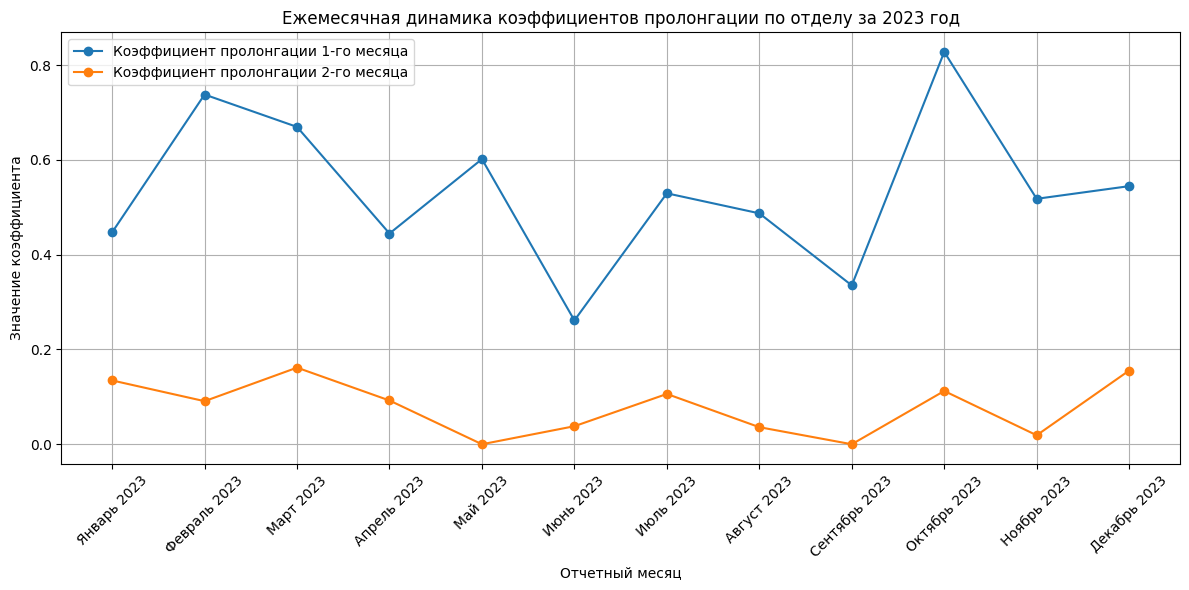

In [ ]:
# Шаг 13. Визуализация ежемесячной динамики коэффициентов по отделу

import matplotlib.pyplot as plt

# 1. Создаем копию таблицы и сортируем по дате
plot_df = department_month_summary.copy().sort_values('report_month_dt')

# 2. Проверим данные, которые пойдут в график
display(plot_df[['report_month', 'coef1', 'coef2']])

# 3. Строим график
plt.figure(figsize=(12, 6))

plt.plot(
    plot_df['report_month'],
    plot_df['coef1'],
    marker='o',
    label='Коэффициент пролонгации 1-го месяца'
)

plt.plot(
    plot_df['report_month'],
    plot_df['coef2'],
    marker='o',
    label='Коэффициент пролонгации 2-го месяца'
)

# 4. Оформление графика
plt.title('Ежемесячная динамика коэффициентов пролонгации по отделу за 2023 год')
plt.xlabel('Отчетный месяц')
plt.ylabel('Значение коэффициента')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()

# 5. Показываем график
plt.show()

**Интерпретация графика ежемесячной динамики по отделу**

График показывает, что на протяжении 2023 года коэффициент пролонгации первого месяца стабильно превышает коэффициент пролонгации второго месяца. Это соответствует логике расчетов: во второй коэффициент попадают только те проекты, которые не были пролонгированы в первый месяц.

Наиболее высокий уровень коэффициента первого месяца наблюдается в октябре 2023 года, тогда как наиболее слабое значение фиксируется в июне 2023 года. Коэффициент второго месяца в целом остается существенно ниже и в отдельные месяцы принимает нулевое значение, что указывает на отсутствие пролонгаций во второй месяц для соответствующей базы проектов.

,AM,coef1_year,projects_count_coef1,rank_coef1_year
1,Manager 07,0.720031,51,2.0
2,Manager 04,0.664941,26,3.0
3,Manager 08,0.584562,72,4.0
4,Manager 01,0.520354,110,5.0
5,Manager 06,0.512296,61,6.0
6,Manager 03,0.478448,15,7.0
7,Manager 02,0.351146,47,8.0


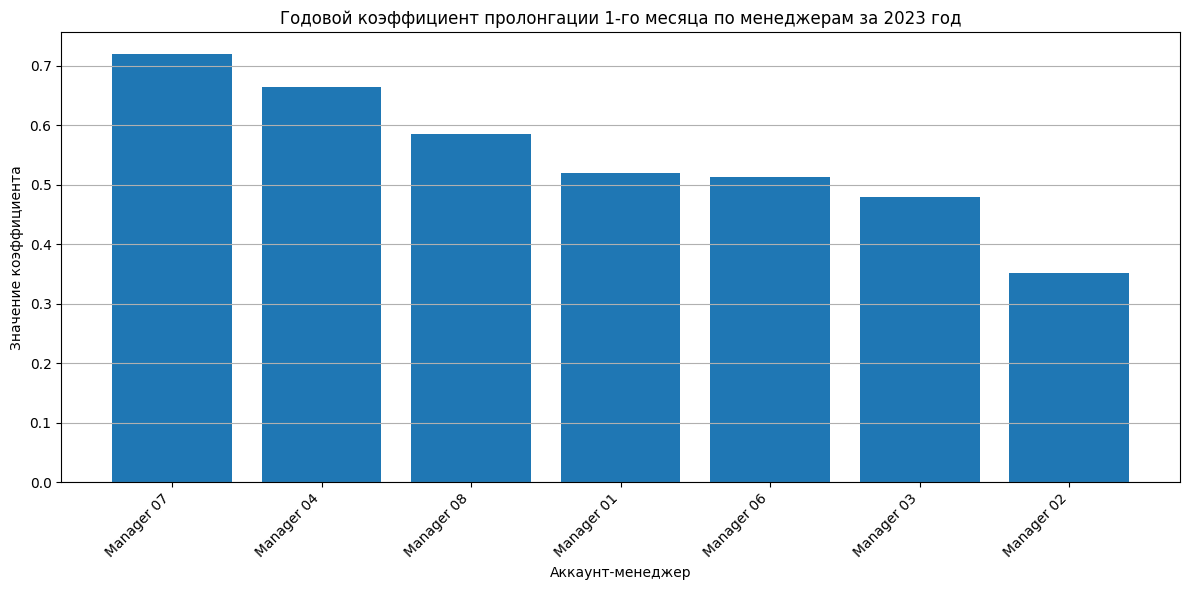

In [ ]:
# Шаг 14. Визуализация годового коэффициента 1 по менеджерам

import matplotlib.pyplot as plt

# 1. Подготовим данные для графика
plot_manager_coef1 = manager_year_summary[
    (~manager_year_summary['special_manager_group']) &
    (~manager_year_summary['low_volume_flag']) &
    (manager_year_summary['coef1_year'].notna())
].copy()

plot_manager_coef1 = plot_manager_coef1.sort_values('coef1_year', ascending=False)

# 2. Покажем таблицу, которая идет в график
display(
    plot_manager_coef1[
        ['AM', 'coef1_year', 'projects_count_coef1', 'rank_coef1_year']
    ]
)

# 3. Строим график
plt.figure(figsize=(12, 6))

plt.bar(
    plot_manager_coef1['AM'],
    plot_manager_coef1['coef1_year']
)

# 4. Оформление
plt.title('Годовой коэффициент пролонгации 1-го месяца по менеджерам за 2023 год')
plt.xlabel('Аккаунт-менеджер')
plt.ylabel('Значение коэффициента')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()

# 5. Показываем график
plt.show()

**Интерпретация графика годового коэффициента первого месяца по менеджерам**

График показывает сравнение аккаунт-менеджеров по годовому коэффициенту пролонгации первого месяца за 2023 год с исключением специальных и низкообъемных случаев из основной визуализации.

Среди сопоставимых наблюдений наиболее высокий результат демонстрирует Manager 7, далее следуют Manager 4 и Manager 8. Наиболее низкое значение среди менеджеров, вошедших в основное сравнение, наблюдается у Manager 2.

При интерпретации графика важно учитывать, что коэффициент отражает отношение сумм отгрузки, а не просто долю проектов. Поэтому для полноценной оценки результатов его следует рассматривать вместе с числом проектов, вошедших в расчет.

,AM,coef2_year,projects_count_coef2,rank_coef2_year
1,Manager 07,0.253671,39.0,1.0
5,Manager 06,0.13787,59.0,2.0
4,Manager 01,0.08291,115.0,3.0
3,Manager 08,0.060343,68.0,4.0
2,Manager 04,0.0,29.0,5.0
6,Manager 03,0.0,9.0,5.0
7,Manager 02,0.0,48.0,5.0


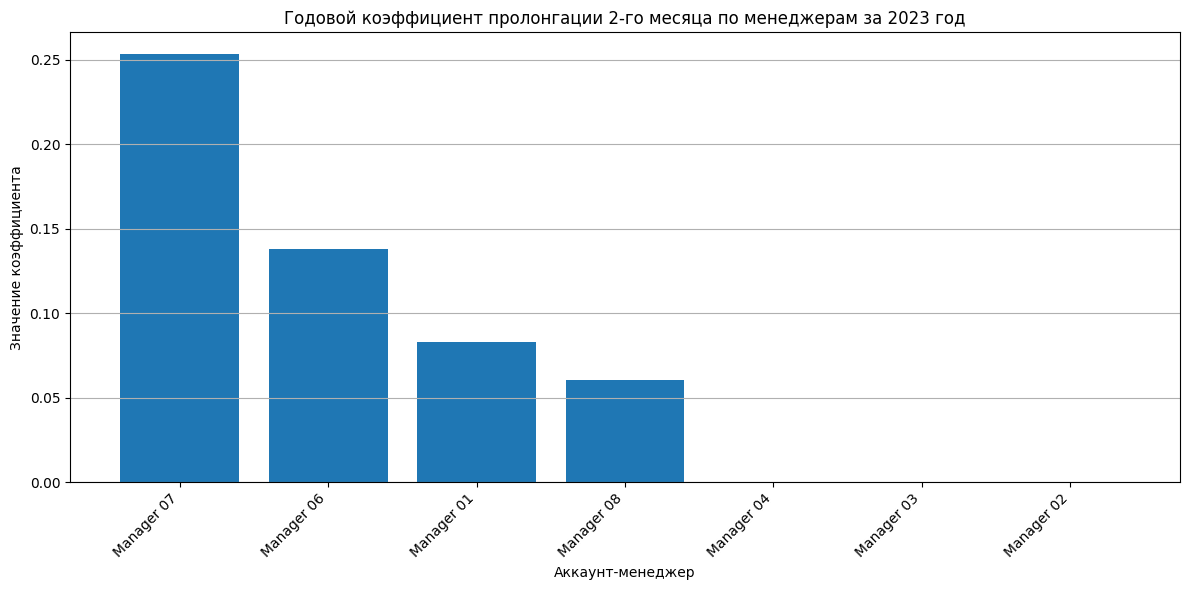

In [ ]:
# Шаг 15. Визуализация годового коэффициента 2 по менеджерам

import matplotlib.pyplot as plt

# 1. Подготовим данные для графика
plot_manager_coef2 = manager_year_summary[
    (~manager_year_summary['special_manager_group']) &
    (~manager_year_summary['low_volume_flag']) &
    (manager_year_summary['coef2_year'].notna())
].copy()

plot_manager_coef2 = plot_manager_coef2.sort_values('coef2_year', ascending=False)

# 2. Покажем таблицу, которая идет в график
display(
    plot_manager_coef2[
        ['AM', 'coef2_year', 'projects_count_coef2', 'rank_coef2_year']
    ]
)

# 3. Строим график
plt.figure(figsize=(12, 6))

plt.bar(
    plot_manager_coef2['AM'],
    plot_manager_coef2['coef2_year']
)

# 4. Оформление
plt.title('Годовой коэффициент пролонгации 2-го месяца по менеджерам за 2023 год')
plt.xlabel('Аккаунт-менеджер')
plt.ylabel('Значение коэффициента')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()

# 5. Показываем график
plt.show()

**Интерпретация графика годового коэффициента второго месяца по менеджерам**

График показывает, что годовой коэффициент пролонгации второго месяца в целом существенно ниже коэффициента первого месяца. Это соответствует логике задачи, поскольку во второй коэффициент попадают только те проекты, которые не были пролонгированы в первый месяц.

Наиболее высокий результат по коэффициенту второго месяца среди сопоставимых наблюдений демонстрирует 	Manager 07, далее следуют Manager 06 и 	Manager 01. У части менеджеров значение коэффициента второго месяца равно нулю, что означает отсутствие пролонгаций во второй месяц в рамках соответствующей базы проектов.

При интерпретации графика также важно учитывать объем базы расчета, поскольку коэффициент следует рассматривать вместе с числом проектов, вошедших в анализ.

In [ ]:
# Шаг 16. Подготовка экспортных таблиц для итогового отчета

# 1. Годовая сводка по отделу — компактная executive-таблица
report_department_year = department_year_summary.copy()

report_department_year = report_department_year.rename(columns={
    'coef1_denominator': 'Знаменатель коэф. 1',
    'coef1_numerator': 'Числитель коэф. 1',
    'projects_count_coef1': 'Количество наблюдений коэф. 1',
    'prolonged_first_count': 'Пролонгировано в 1-й месяц',
    'coef1_year': 'Коэффициент 1 за 2023',
    'coef2_denominator': 'Знаменатель коэф. 2',
    'coef2_numerator': 'Числитель коэф. 2',
    'projects_count_coef2': 'Количество наблюдений коэф. 2',
    'eligible_second_count': 'База для коэф. 2',
    'prolonged_second_count': 'Пролонгировано во 2-й месяц',
    'coef2_year': 'Коэффициент 2 за 2023'
})

report_department_year['Коэффициент 1 за 2023, %'] = (report_department_year['Коэффициент 1 за 2023'] * 100).round(2)
report_department_year['Коэффициент 2 за 2023, %'] = (report_department_year['Коэффициент 2 за 2023'] * 100).round(2)

# 2. Годовая сводка по менеджерам
report_manager_year = manager_year_summary.copy()

report_manager_year = report_manager_year.rename(columns={
    'AM': 'Аккаунт-менеджер',
    'coef1_denominator': 'Знаменатель коэф. 1',
    'coef1_numerator': 'Числитель коэф. 1',
    'projects_count_coef1': 'Количество наблюдений коэф. 1',
    'prolonged_first_count': 'Пролонгировано в 1-й месяц',
    'coef1_year': 'Коэффициент 1 за 2023',
    'coef2_denominator': 'Знаменатель коэф. 2',
    'coef2_numerator': 'Числитель коэф. 2',
    'projects_count_coef2': 'Количество наблюдений коэф. 2',
    'eligible_second_count': 'База для коэф. 2',
    'prolonged_second_count': 'Пролонгировано во 2-й месяц',
    'coef2_year': 'Коэффициент 2 за 2023',
    'special_manager_group': 'Спецкатегория',
    'low_volume_flag': 'Низкий объем',
    'rank_coef1_year': 'Ранг по коэф. 1',
    'rank_coef2_year': 'Ранг по коэф. 2'
})

report_manager_year['Коэффициент 1 за 2023, %'] = (report_manager_year['Коэффициент 1 за 2023'] * 100).round(2)
report_manager_year['Коэффициент 2 за 2023, %'] = (report_manager_year['Коэффициент 2 за 2023'] * 100).round(2)

# Для удобства чтения разместим ключевые колонки ближе к началу
report_manager_year = report_manager_year[
    [
        'Аккаунт-менеджер',
        'Коэффициент 1 за 2023',
        'Коэффициент 1 за 2023, %',
        'Коэффициент 2 за 2023',
        'Коэффициент 2 за 2023, %',
        'Количество наблюдений коэф. 1',
        'Количество наблюдений коэф. 2',
        'Пролонгировано в 1-й месяц',
        'База для коэф. 2',
        'Пролонгировано во 2-й месяц',
        'Ранг по коэф. 1',
        'Ранг по коэф. 2',
        'Низкий объем',
        'Спецкатегория',
        'Знаменатель коэф. 1',
        'Числитель коэф. 1',
        'Знаменатель коэф. 2',
        'Числитель коэф. 2'
    ]
].copy()

# 3. Ежемесячная сводка по отделу
report_department_month = department_month_summary.copy()

report_department_month = report_department_month.rename(columns={
    'report_month_dt': 'Дата отчетного месяца',
    'report_month': 'Отчетный месяц',
    'coef1_denominator': 'Знаменатель коэф. 1',
    'coef1_numerator': 'Числитель коэф. 1',
    'projects_count_coef1': 'Количество наблюдений коэф. 1',
    'prolonged_first_count': 'Пролонгировано в 1-й месяц',
    'coef1': 'Коэффициент 1',
    'coef2_denominator': 'Знаменатель коэф. 2',
    'coef2_numerator': 'Числитель коэф. 2',
    'projects_count_coef2': 'Количество наблюдений коэф. 2',
    'eligible_second_count': 'База для коэф. 2',
    'prolonged_second_count': 'Пролонгировано во 2-й месяц',
    'coef2': 'Коэффициент 2'
})

report_department_month['Коэффициент 1, %'] = (report_department_month['Коэффициент 1'] * 100).round(2)
report_department_month['Коэффициент 2, %'] = (report_department_month['Коэффициент 2'] * 100).round(2)

report_department_month = report_department_month[
    [
        'Дата отчетного месяца',
        'Отчетный месяц',
        'Коэффициент 1',
        'Коэффициент 1, %',
        'Коэффициент 2',
        'Коэффициент 2, %',
        'Количество наблюдений коэф. 1',
        'Пролонгировано в 1-й месяц',
        'Количество наблюдений коэф. 2',
        'База для коэф. 2',
        'Пролонгировано во 2-й месяц',
        'Знаменатель коэф. 1',
        'Числитель коэф. 1',
        'Знаменатель коэф. 2',
        'Числитель коэф. 2'
    ]
].copy()

# 4. Поддерживающие таблицы для графиков
report_chart_coef1 = plot_manager_coef1.copy()
report_chart_coef1 = report_chart_coef1.rename(columns={
    'AM': 'Аккаунт-менеджер',
    'coef1_year': 'Коэффициент 1 за 2023',
    'projects_count_coef1': 'Количество наблюдений',
    'rank_coef1_year': 'Ранг'
})
report_chart_coef1['Коэффициент 1 за 2023, %'] = (report_chart_coef1['Коэффициент 1 за 2023'] * 100).round(2)

report_chart_coef2 = plot_manager_coef2.copy()
report_chart_coef2 = report_chart_coef2.rename(columns={
    'AM': 'Аккаунт-менеджер',
    'coef2_year': 'Коэффициент 2 за 2023',
    'projects_count_coef2': 'Количество наблюдений',
    'rank_coef2_year': 'Ранг'
})
report_chart_coef2['Коэффициент 2 за 2023, %'] = (report_chart_coef2['Коэффициент 2 за 2023'] * 100).round(2)

# 5. Покажем итоговые таблицы
print("report_department_year")
display(report_department_year)

print("\nreport_manager_year")
display(report_manager_year)

print("\nreport_department_month")
display(report_department_month)

print("\nreport_chart_coef1")
display(report_chart_coef1)

print("\nreport_chart_coef2")
display(report_chart_coef2)

report_department_year


,Знаменатель коэф. 1,Числитель коэф. 1,Количество наблюдений коэф. 1,Пролонгировано в 1-й месяц,Коэффициент 1 за 2023,Знаменатель коэф. 2,Числитель коэф. 2,Количество наблюдений коэф. 2,База для коэф. 2,Пролонгировано во 2-й месяц,Коэффициент 2 за 2023,"Коэффициент 1 за 2023, %","Коэффициент 2 за 2023, %"
0,34362627.23,18580020.04,384,161,0.540704,14913472.87,1097390.58,368,211,18,0.073584,54.07,7.36



report_manager_year


,Аккаунт-менеджер,Коэффициент 1 за 2023,"Коэффициент 1 за 2023, %",Коэффициент 2 за 2023,"Коэффициент 2 за 2023, %",Количество наблюдений коэф. 1,Количество наблюдений коэф. 2,Пролонгировано в 1-й месяц,База для коэф. 2,Пролонгировано во 2-й месяц,Ранг по коэф. 1,Ранг по коэф. 2,Низкий объем,Спецкатегория,Знаменатель коэф. 1,Числитель коэф. 1,Знаменатель коэф. 2,Числитель коэф. 2
0,Manager 05,1.111182,111.118182,NaN,NaN,1,NaN,1,NaN,NaN,1.0,NaN,True,False,98492.00,109442.52,NaN,NaN
1,Manager 07,0.720031,72.00309,0.253671,25.367118,51,39.0,22,21.0,4.0,2.0,1.0,False,False,2951204.59,2124958.50,803500.80,203825.00
2,Manager 04,0.664941,66.494139,0.0,0.0,26,29.0,14,13.0,0.0,3.0,5.0,False,False,3361833.59,2235422.29,1056004.68,0.00
3,Manager 08,0.584562,58.456167,0.060343,6.034319,72,68.0,34,36.0,3.0,4.0,4.0,False,False,6798714.58,3974267.97,2812661.98,169725.00
4,Manager 01,0.520354,52.035435,0.08291,8.291019,110,115.0,43,69.0,7.0,5.0,3.0,False,False,11761147.79,6119964.43,5818845.40,482441.58
5,Manager 06,0.512296,51.229586,0.13787,13.786979,61,59.0,25,34.0,4.0,6.0,2.0,False,False,3680853.08,1885685.80,1750920.26,241399.00
6,Manager 03,0.478448,47.844844,0.0,0.0,15,9.0,7,4.0,0.0,7.0,5.0,False,False,982724.44,470182.98,167675.00,0.00
7,Manager 02,0.351146,35.11455,0.0,0.0,47,48.0,15,33.0,0.0,8.0,5.0,False,False,4727657.16,1660095.55,2503864.75,0.00
8,Manager 10,<NA>,<NA>,<NA>,<NA>,1,1.0,0,1.0,0.0,NaN,NaN,True,False,0.00,0.00,0.00,0.00



report_department_month


,Дата отчетного месяца,Отчетный месяц,Коэффициент 1,"Коэффициент 1, %",Коэффициент 2,"Коэффициент 2, %",Количество наблюдений коэф. 1,Пролонгировано в 1-й месяц,Количество наблюдений коэф. 2,База для коэф. 2,Пролонгировано во 2-й месяц,Знаменатель коэф. 1,Числитель коэф. 1,Знаменатель коэф. 2,Числитель коэф. 2
0,2023-01-01,Январь 2023,0.447156,44.72,0.134637,13.46,67,23,24,14,1,5986766.86,2677021.61,545022.00,73380.00
1,2023-02-01,Февраль 2023,0.737893,73.79,0.090871,9.09,20,6,67,44,4,2549075.50,1880945.00,2890042.76,262620.00
2,2023-03-01,Март 2023,0.669572,66.96,0.161662,16.17,28,13,20,14,2,1899332.77,1271739.40,760840.50,122999.08
3,2023-04-01,Апрель 2023,0.444653,44.47,0.092300,9.23,33,16,28,15,2,3377742.20,1501923.35,627735.00,57940.00
4,2023-05-01,Май 2023,0.601645,60.16,0.000000,0.00,28,18,33,17,0,3647436.50,2194460.75,1796703.80,0.00
5,2023-06-01,Июнь 2023,0.261307,26.13,0.038059,3.81,22,4,28,10,1,1274625.53,333068.28,1015068.50,38632.50
6,2023-07-01,Июль 2023,0.529482,52.95,0.106128,10.61,31,14,22,18,2,2625982.85,1390411.00,1020325.53,108285.00
7,2023-08-01,Август 2023,0.487207,48.72,0.036017,3.60,23,12,31,17,1,1936915.83,943678.88,1452499.85,52315.00
8,2023-09-01,Сентябрь 2023,0.335136,33.51,0.000000,0.00,26,10,23,11,0,3241978.50,1086504.42,755739.63,0.00
9,2023-10-01,Октябрь 2023,0.827750,82.77,0.112397,11.24,42,21,26,16,2,3820835.81,3162695.19,2183145.12,245379.00



report_chart_coef1


,Аккаунт-менеджер,coef1_denominator,coef1_numerator,Количество наблюдений,prolonged_first_count,Коэффициент 1 за 2023,coef2_denominator,coef2_numerator,projects_count_coef2,eligible_second_count,prolonged_second_count,coef2_year,special_manager_group,low_volume_flag,Ранг,rank_coef2_year,"Коэффициент 1 за 2023, %"
1,Manager 07,2951204.59,2124958.50,51,22,0.720031,803500.80,203825.00,39.0,21.0,4.0,0.253671,False,False,2.0,1.0,72.00309
2,Manager 04,3361833.59,2235422.29,26,14,0.664941,1056004.68,0.00,29.0,13.0,0.0,0.0,False,False,3.0,5.0,66.494139
3,Manager 08,6798714.58,3974267.97,72,34,0.584562,2812661.98,169725.00,68.0,36.0,3.0,0.060343,False,False,4.0,4.0,58.456167
4,Manager 01,11761147.79,6119964.43,110,43,0.520354,5818845.40,482441.58,115.0,69.0,7.0,0.08291,False,False,5.0,3.0,52.035435
5,Manager 06,3680853.08,1885685.80,61,25,0.512296,1750920.26,241399.00,59.0,34.0,4.0,0.13787,False,False,6.0,2.0,51.229586
6,Manager 03,982724.44,470182.98,15,7,0.478448,167675.00,0.00,9.0,4.0,0.0,0.0,False,False,7.0,5.0,47.844844
7,Manager 02,4727657.16,1660095.55,47,15,0.351146,2503864.75,0.00,48.0,33.0,0.0,0.0,False,False,8.0,5.0,35.11455



report_chart_coef2


,Аккаунт-менеджер,coef1_denominator,coef1_numerator,projects_count_coef1,prolonged_first_count,coef1_year,coef2_denominator,coef2_numerator,Количество наблюдений,eligible_second_count,prolonged_second_count,Коэффициент 2 за 2023,special_manager_group,low_volume_flag,rank_coef1_year,Ранг,"Коэффициент 2 за 2023, %"
1,Manager 07,2951204.59,2124958.50,51,22,0.720031,803500.80,203825.00,39.0,21.0,4.0,0.253671,False,False,2.0,1.0,25.367118
5,Manager 06,3680853.08,1885685.80,61,25,0.512296,1750920.26,241399.00,59.0,34.0,4.0,0.13787,False,False,6.0,2.0,13.786979
4,Manager 01,11761147.79,6119964.43,110,43,0.520354,5818845.40,482441.58,115.0,69.0,7.0,0.08291,False,False,5.0,3.0,8.291019
3,Manager 08,6798714.58,3974267.97,72,34,0.584562,2812661.98,169725.00,68.0,36.0,3.0,0.060343,False,False,4.0,4.0,6.034319
2,Manager 04,3361833.59,2235422.29,26,14,0.664941,1056004.68,0.00,29.0,13.0,0.0,0.0,False,False,3.0,5.0,0.0
6,Manager 03,982724.44,470182.98,15,7,0.478448,167675.00,0.00,9.0,4.0,0.0,0.0,False,False,7.0,5.0,0.0
7,Manager 02,4727657.16,1660095.55,47,15,0.351146,2503864.75,0.00,48.0,33.0,0.0,0.0,False,False,8.0,5.0,0.0


**Подготовка таблиц для переноса в итоговый отчет**

На данном этапе были сформированы финальные таблицы, предназначенные для переноса в Google Sheets.

В отличие от промежуточных расчетных таблиц, эти версии ориентированы на использование в аналитическом отчете:
- имеют более понятные названия столбцов,
- содержат коэффициенты как в исходном виде, так и в формате процентов,
- включают только те показатели, которые необходимы для интерпретации результатов руководителем отдела.

Дополнительно были подготовлены компактные таблицы-подписи для графиков, чтобы при необходимости рядом с визуализациями можно было показать объем наблюдений, входящих в расчет.

In [ ]:
# Шаг 17. Финальная очистка компактных таблиц для графиков

# 1. Компактная таблица для графика коэффициента 1
report_chart_coef1_final = plot_manager_coef1[
    ['AM', 'coef1_year', 'projects_count_coef1', 'rank_coef1_year']
].copy()

report_chart_coef1_final = report_chart_coef1_final.rename(columns={
    'AM': 'Аккаунт-менеджер',
    'coef1_year': 'Коэффициент 1 за 2023',
    'projects_count_coef1': 'Количество наблюдений',
    'rank_coef1_year': 'Ранг'
})

report_chart_coef1_final['Коэффициент 1 за 2023, %'] = (
    report_chart_coef1_final['Коэффициент 1 за 2023'] * 100
).round(2)

report_chart_coef1_final = report_chart_coef1_final[
    ['Аккаунт-менеджер', 'Коэффициент 1 за 2023', 'Коэффициент 1 за 2023, %', 'Количество наблюдений', 'Ранг']
].copy()

# 2. Компактная таблица для графика коэффициента 2
report_chart_coef2_final = plot_manager_coef2[
    ['AM', 'coef2_year', 'projects_count_coef2', 'rank_coef2_year']
].copy()

report_chart_coef2_final = report_chart_coef2_final.rename(columns={
    'AM': 'Аккаунт-менеджер',
    'coef2_year': 'Коэффициент 2 за 2023',
    'projects_count_coef2': 'Количество наблюдений',
    'rank_coef2_year': 'Ранг'
})

report_chart_coef2_final['Коэффициент 2 за 2023, %'] = (
    report_chart_coef2_final['Коэффициент 2 за 2023'] * 100
).round(2)

report_chart_coef2_final = report_chart_coef2_final[
    ['Аккаунт-менеджер', 'Коэффициент 2 за 2023', 'Коэффициент 2 за 2023, %', 'Количество наблюдений', 'Ранг']
].copy()

# 3. Просмотр итоговых таблиц
print("report_chart_coef1_final")
display(report_chart_coef1_final)

print("\nreport_chart_coef2_final")
display(report_chart_coef2_final)

report_chart_coef1_final


,Аккаунт-менеджер,Коэффициент 1 за 2023,"Коэффициент 1 за 2023, %",Количество наблюдений,Ранг
1,Manager 07,0.720031,72.00309,51,2.0
2,Manager 04,0.664941,66.494139,26,3.0
3,Manager 08,0.584562,58.456167,72,4.0
4,Manager 01,0.520354,52.035435,110,5.0
5,Manager 06,0.512296,51.229586,61,6.0
6,Manager 03,0.478448,47.844844,15,7.0
7,Manager 02,0.351146,35.11455,47,8.0



report_chart_coef2_final


,Аккаунт-менеджер,Коэффициент 2 за 2023,"Коэффициент 2 за 2023, %",Количество наблюдений,Ранг
1,Manager 07,0.253671,25.367118,39.0,1.0
5,Manager 06,0.13787,13.786979,59.0,2.0
4,Manager 01,0.08291,8.291019,115.0,3.0
3,Manager 08,0.060343,6.034319,68.0,4.0
2,Manager 04,0.0,0.0,29.0,5.0
6,Manager 03,0.0,0.0,9.0,5.0
7,Manager 02,0.0,0.0,48.0,5.0


In [ ]:
# Шаг 18. Подготовка ежемесячной сводной таблицы по менеджерам для итогового отчета

# 1. Копии месячных таблиц
monthly_m1 = coef1_manager_monthly.copy()
monthly_m2 = coef2_manager_monthly.copy()

# 2. Переименуем столбцы коэффициента 1
monthly_m1 = monthly_m1.rename(columns={
    'report_month_first_dt': 'Дата отчетного месяца',
    'report_month_first': 'Отчетный месяц',
    'AM': 'Аккаунт-менеджер',
    'coef1_denominator': 'Знаменатель коэф. 1',
    'coef1_numerator': 'Числитель коэф. 1',
    'projects_count': 'Количество наблюдений коэф. 1',
    'prolonged_first_count': 'Пролонгировано в 1-й месяц',
    'coef1': 'Коэффициент 1'
})

# 3. Переименуем столбцы коэффициента 2
monthly_m2 = monthly_m2.rename(columns={
    'report_month_second_dt': 'Дата отчетного месяца',
    'report_month_second': 'Отчетный месяц',
    'AM': 'Аккаунт-менеджер',
    'coef2_denominator': 'Знаменатель коэф. 2',
    'coef2_numerator': 'Числитель коэф. 2',
    'projects_count': 'Количество наблюдений коэф. 2',
    'eligible_second_count': 'База для коэф. 2',
    'prolonged_second_count': 'Пролонгировано во 2-й месяц',
    'coef2': 'Коэффициент 2'
})

# 4. Объединяем по месяцу и менеджеру
report_manager_month = monthly_m1.merge(
    monthly_m2,
    on=['Дата отчетного месяца', 'Отчетный месяц', 'Аккаунт-менеджер'],
    how='outer'
)

# 5. Добавим процентные колонки
report_manager_month['Коэффициент 1, %'] = (report_manager_month['Коэффициент 1'] * 100).round(2)
report_manager_month['Коэффициент 2, %'] = (report_manager_month['Коэффициент 2'] * 100).round(2)

# 6. Упорядочим столбцы
report_manager_month = report_manager_month[
    [
        'Дата отчетного месяца',
        'Отчетный месяц',
        'Аккаунт-менеджер',
        'Коэффициент 1',
        'Коэффициент 1, %',
        'Коэффициент 2',
        'Коэффициент 2, %',
        'Количество наблюдений коэф. 1',
        'Пролонгировано в 1-й месяц',
        'Количество наблюдений коэф. 2',
        'База для коэф. 2',
        'Пролонгировано во 2-й месяц',
        'Знаменатель коэф. 1',
        'Числитель коэф. 1',
        'Знаменатель коэф. 2',
        'Числитель коэф. 2'
    ]
].copy()

# 7. Сортировка
report_manager_month = report_manager_month.sort_values(
    ['Дата отчетного месяца', 'Аккаунт-менеджер']
).reset_index(drop=True)

# 8. Проверка результата
print("report_manager_month")
display(report_manager_month.head(20))

print("\nРазмер итоговой таблицы")
print(report_manager_month.shape)

print("\nКоличество уникальных месяцев")
print(report_manager_month['Отчетный месяц'].nunique())

print("\nКоличество уникальных менеджеров")
print(report_manager_month['Аккаунт-менеджер'].nunique())

report_manager_month


,Дата отчетного месяца,Отчетный месяц,Аккаунт-менеджер,Коэффициент 1,"Коэффициент 1, %",Коэффициент 2,"Коэффициент 2, %",Количество наблюдений коэф. 1,Пролонгировано в 1-й месяц,Количество наблюдений коэф. 2,База для коэф. 2,Пролонгировано во 2-й месяц,Знаменатель коэф. 1,Числитель коэф. 1,Знаменатель коэф. 2,Числитель коэф. 2
0,2023-01-01,Январь 2023,Manager 01,0.556236,55.623583,0.0,0.0,22.0,6.0,12.0,8.0,0.0,1693097.68,941761.60,260862.00,0.00
1,2023-01-01,Январь 2023,Manager 02,0.270066,27.006578,0.0,0.0,16.0,4.0,1.0,1.0,0.0,2296595.71,620231.92,52240.00,0.00
2,2023-01-01,Январь 2023,Manager 03,1.265979,126.597879,NaN,NaN,1.0,1.0,NaN,NaN,NaN,52335.00,66255.00,NaN,NaN
3,2023-01-01,Январь 2023,Manager 04,0.687923,68.792342,0.0,0.0,10.0,4.0,4.0,2.0,0.0,641080.21,441014.09,41025.00,0.00
4,2023-01-01,Январь 2023,Manager 06,0.440678,44.067832,0.0,0.0,6.0,2.0,2.0,1.0,0.0,242070.00,106675.00,82800.00,0.00
5,2023-01-01,Январь 2023,Manager 07,0.743395,74.339497,NaN,NaN,3.0,2.0,NaN,NaN,NaN,150075.00,111565.00,NaN,NaN
6,2023-01-01,Январь 2023,Manager 08,0.427332,42.733224,0.678847,67.884731,9.0,4.0,5.0,2.0,1.0,911513.26,389519.00,108095.00,73380.00
7,2023-02-01,Февраль 2023,Manager 01,1.155761,115.576052,0.186546,18.654602,5.0,2.0,22.0,16.0,2.0,756225.00,874015.00,891335.00,166275.00
8,2023-02-01,Февраль 2023,Manager 02,NaN,NaN,0.0,0.0,NaN,NaN,16.0,12.0,0.0,NaN,NaN,1229435.00,0.00
9,2023-02-01,Февраль 2023,Manager 03,0.846955,84.695495,<NA>,<NA>,2.0,1.0,1.0,0.0,0.0,66255.00,56115.00,0.00,0.00



Размер итоговой таблицы
(82, 16)

Количество уникальных месяцев
12

Количество уникальных менеджеров
9


**Подготовка ежемесячной сводной таблицы по менеджерам**

Для выполнения требования задачи по расчету коэффициентов за каждый месяц и по каждому аккаунт-менеджеру была подготовлена отдельная сводная таблица `report_manager_month`.

В этой таблице для каждого отчетного месяца и каждого менеджера объединены:
- коэффициент пролонгации первого месяца,
- коэффициент пролонгации второго месяца,
- вспомогательные показатели объема и базы расчета,
- числители и знаменатели по обеим формулам.

Такая структура удобна для переноса в итоговый Google Sheets-отчет и позволяет анализировать как итоговые значения коэффициентов, так и их расчетную основу.

In [ ]:
march_april_export = report_manager_month[
    report_manager_month['Отчетный месяц'].isin(['Март 2023', 'Апрель 2023'])
][[
    'Отчетный месяц',
    'Аккаунт-менеджер',
    'Коэффициент 1, %',
    'Коэффициент 2, %',
    'Количество наблюдений коэф. 1',
    'Пролонгировано в 1-й месяц',
    'Количество наблюдений коэф. 2',
    'База для коэф. 2',
    'Пролонгировано во 2-й месяц'
]].copy()

display(march_april_export)

,Отчетный месяц,Аккаунт-менеджер,"Коэффициент 1, %","Коэффициент 2, %",Количество наблюдений коэф. 1,Пролонгировано в 1-й месяц,Количество наблюдений коэф. 2,База для коэф. 2,Пролонгировано во 2-й месяц
14,Март 2023,Manager 01,62.724961,70.782329,9.0,5.0,5.0,3.0,1.0
15,Март 2023,Manager 02,44.607446,NaN,4.0,1.0,NaN,NaN,NaN
16,Март 2023,Manager 03,<NA>,<NA>,1.0,0.0,2.0,1.0,0.0
17,Март 2023,Manager 04,243.057702,<NA>,1.0,1.0,2.0,0.0,0.0
18,Март 2023,Manager 06,68.452327,0.0,7.0,3.0,4.0,4.0,0.0
19,Март 2023,Manager 07,NaN,115.052083,NaN,NaN,1.0,1.0,1.0
20,Март 2023,Manager 08,93.921947,0.0,6.0,3.0,6.0,5.0,0.0
21,Апрель 2023,Manager 01,35.124815,11.020341,13.0,5.0,9.0,4.0,1.0
22,Апрель 2023,Manager 02,27.768283,0.0,4.0,2.0,4.0,3.0,0.0
23,Апрель 2023,Manager 03,0.0,<NA>,1.0,0.0,1.0,1.0,0.0


In [ ]:
may_june_export = report_manager_month[
    report_manager_month['Отчетный месяц'].isin(['Май 2023', 'Июнь 2023'])
][[
    'Отчетный месяц',
    'Аккаунт-менеджер',
    'Коэффициент 1, %',
    'Коэффициент 2, %',
    'Количество наблюдений коэф. 1',
    'Пролонгировано в 1-й месяц',
    'Количество наблюдений коэф. 2',
    'База для коэф. 2',
    'Пролонгировано во 2-й месяц'
]].copy()

display(may_june_export)

,Отчетный месяц,Аккаунт-менеджер,"Коэффициент 1, %","Коэффициент 2, %",Количество наблюдений коэф. 1,Пролонгировано в 1-й месяц,Количество наблюдений коэф. 2,База для коэф. 2,Пролонгировано во 2-й месяц
28,Май 2023,Manager 01,49.690974,0.0,12.0,7.0,13.0,8.0,0.0
29,Май 2023,Manager 02,100.0,0.0,1.0,1.0,4.0,2.0,0.0
30,Май 2023,Manager 03,NaN,0.0,NaN,NaN,1.0,1.0,0.0
31,Май 2023,Manager 04,118.961592,<NA>,3.0,2.0,2.0,0.0,0.0
32,Май 2023,Manager 06,75.694766,0.0,8.0,6.0,7.0,5.0,0.0
33,Май 2023,Manager 07,NaN,<NA>,NaN,NaN,2.0,0.0,0.0
34,Май 2023,Manager 08,23.740644,0.0,4.0,2.0,4.0,1.0,0.0
35,Июнь 2023,Manager 01,38.928704,5.696257,5.0,2.0,12.0,5.0,1.0
36,Июнь 2023,Manager 02,0.0,<NA>,7.0,0.0,1.0,0.0,0.0
37,Июнь 2023,Manager 04,0.0,<NA>,1.0,0.0,3.0,1.0,0.0


In [ ]:
july_august_export = report_manager_month[
    report_manager_month['Отчетный месяц'].isin(['Июль 2023', 'Август 2023'])
][[
    'Отчетный месяц',
    'Аккаунт-менеджер',
    'Коэффициент 1, %',
    'Коэффициент 2, %',
    'Количество наблюдений коэф. 1',
    'Пролонгировано в 1-й месяц',
    'Количество наблюдений коэф. 2',
    'База для коэф. 2',
    'Пролонгировано во 2-й месяц'
]].copy()

display(july_august_export)


,Отчетный месяц,Аккаунт-менеджер,"Коэффициент 1, %","Коэффициент 2, %",Количество наблюдений коэф. 1,Пролонгировано в 1-й месяц,Количество наблюдений коэф. 2,База для коэф. 2,Пролонгировано во 2-й месяц
41,Июль 2023,Manager 01,58.501567,0.0,10.0,5.0,5.0,3.0,0.0
42,Июль 2023,Manager 02,47.261057,0.0,6.0,2.0,7.0,7.0,0.0
43,Июль 2023,Manager 04,119.752463,0.0,1.0,1.0,1.0,1.0,0.0
44,Июль 2023,Manager 06,9.605189,50.578598,4.0,1.0,3.0,3.0,1.0
45,Июль 2023,Manager 07,0.0,51.627914,2.0,0.0,3.0,2.0,1.0
46,Июль 2023,Manager 08,61.90881,0.0,8.0,5.0,3.0,2.0,0.0
47,Август 2023,Manager 01,47.750385,0.0,5.0,3.0,10.0,5.0,0.0
48,Август 2023,Manager 02,54.067455,0.0,5.0,3.0,6.0,4.0,0.0
49,Август 2023,Manager 04,NaN,<NA>,NaN,NaN,1.0,0.0,0.0
50,Август 2023,Manager 06,47.993608,0.0,4.0,2.0,4.0,3.0,0.0


In [ ]:
sep_oct_export = report_manager_month[
    report_manager_month['Отчетный месяц'].isin(['Сентябрь 2023', 'Октябрь 2023'])
][[
    'Отчетный месяц',
    'Аккаунт-менеджер',
    'Коэффициент 1, %',
    'Коэффициент 2, %',
    'Количество наблюдений коэф. 1',
    'Пролонгировано в 1-й месяц',
    'Количество наблюдений коэф. 2',
    'База для коэф. 2',
    'Пролонгировано во 2-й месяц'
]].copy()

display(sep_oct_export)

,Отчетный месяц,Аккаунт-менеджер,"Коэффициент 1, %","Коэффициент 2, %",Количество наблюдений коэф. 1,Пролонгировано в 1-й месяц,Количество наблюдений коэф. 2,База для коэф. 2,Пролонгировано во 2-й месяц
54,Сентябрь 2023,Manager 01,17.243259,0.0,8.0,3.0,5.0,2.0,0.0
55,Сентябрь 2023,Manager 02,99.85489,0.0,3.0,2.0,5.0,2.0,0.0
56,Сентябрь 2023,Manager 04,0.0,NaN,1.0,0.0,NaN,NaN,NaN
57,Сентябрь 2023,Manager 06,45.438255,0.0,4.0,1.0,4.0,2.0,0.0
58,Сентябрь 2023,Manager 07,76.547038,0.0,4.0,3.0,4.0,2.0,0.0
59,Сентябрь 2023,Manager 08,29.472005,0.0,6.0,1.0,4.0,2.0,0.0
60,Сентябрь 2023,Manager 10,NaN,<NA>,NaN,NaN,1.0,1.0,0.0
61,Октябрь 2023,Manager 01,88.675038,7.225636,6.0,1.0,8.0,5.0,1.0
62,Октябрь 2023,Manager 02,<NA>,<NA>,1.0,0.0,3.0,1.0,0.0
63,Октябрь 2023,Manager 03,130.851543,NaN,1.0,1.0,NaN,NaN,NaN


In [ ]:
nov_dec_export = report_manager_month[
    report_manager_month['Отчетный месяц'].isin(['Ноябрь 2023', 'Декабрь 2023'])
][[
    'Отчетный месяц',
    'Аккаунт-менеджер',
    'Коэффициент 1, %',
    'Коэффициент 2, %',
    'Количество наблюдений коэф. 1',
    'Пролонгировано в 1-й месяц',
    'Количество наблюдений коэф. 2',
    'База для коэф. 2',
    'Пролонгировано во 2-й месяц'
]].copy()

display(nov_dec_export)


,Отчетный месяц,Аккаунт-менеджер,"Коэффициент 1, %","Коэффициент 2, %",Количество наблюдений коэф. 1,Пролонгировано в 1-й месяц,Количество наблюдений коэф. 2,База для коэф. 2,Пролонгировано во 2-й месяц
68,Ноябрь 2023,Manager 01,62.100069,0.0,8.0,3.0,6.0,5.0,0.0
69,Ноябрь 2023,Manager 02,NaN,<NA>,NaN,NaN,1.0,1.0,0.0
70,Ноябрь 2023,Manager 03,47.364148,<NA>,3.0,2.0,1.0,0.0,0.0
71,Ноябрь 2023,Manager 04,NaN,0.0,NaN,NaN,4.0,2.0,0.0
72,Ноябрь 2023,Manager 06,NaN,18.983705,NaN,NaN,10.0,3.0,1.0
73,Ноябрь 2023,Manager 07,83.623706,0.0,10.0,4.0,10.0,6.0,0.0
74,Ноябрь 2023,Manager 08,17.862629,0.0,3.0,1.0,10.0,4.0,0.0
75,Декабрь 2023,Manager 01,32.406316,48.485856,7.0,1.0,8.0,5.0,1.0
76,Декабрь 2023,Manager 03,27.401166,0.0,6.0,2.0,3.0,1.0,0.0
77,Декабрь 2023,Manager 04,0.0,NaN,1.0,0.0,NaN,NaN,NaN
